# 03 · Testes Estatísticos — Projeto Vértice (Vértice Retail)

**Objetivo deste notebook:** transformar os padrões vistos visualmente em
`02_analise_exploratoria.ipynb` em **evidência estatística formal** — com teste de
hipótese, p-valor e tamanho de efeito — para que o diagnóstico executivo não se
apoie só em "parece que...".

Convenções usadas neste notebook:

- **Nível de significância:** α = 0,05 em todos os testes.
- **Teste paramétrico vs não paramétrico:** as métricas financeiras de pedido
  (`margem_pct`, `margem_contribuicao`, `desconto_pct`) são **assimetricamente
  distribuídas e com variância desigual entre grupos** (confirmado abaixo com
  histograma + teste de Levene). Por isso, para comparação entre grupos usamos
  **Kruskal-Wallis** (não paramétrico, equivalente à ANOVA) em vez de ANOVA
  clássica — mais robusto a essa violação de premissas. Reportamos o resultado das
  duas quando relevante para transparência.
- **Post-hoc:** quando Kruskal-Wallis indica diferença significativa entre 3+
  grupos, fazemos comparações par-a-par com **Mann-Whitney U** e correção de
  **Bonferroni** (α ajustado = 0,05 / nº de pares) para não inflar falso-positivo.
- **Tamanho de efeito:** reportado sempre, porque com bases de milhares de linhas
  quase tudo dá "estatisticamente significativo" — o que importa para a diretoria é
  se a diferença é **relevante em magnitude**, não só se p < 0,05.
  - Correlação: r de Pearson / ρ de Spearman.
  - Kruskal-Wallis: ε² (epsilon-quadrado, análogo ao η² da ANOVA).
  - Mann-Whitney: r = Z / √n (regra de bolso: 0,1 pequeno, 0,3 médio, 0,5 grande).
  - Qui-quadrado: V de Cramér.

Cada seção testa uma das perguntas levantadas na síntese visual do notebook 02.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy import stats

%matplotlib inline
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

ALPHA = 0.05
PALETTE = {'primary': '#2C6E8F', 'accent': '#D9782D', 'good': '#3C8A5B',
           'bad': '#C24A4A', 'neutral': '#8A8F98'}

PROC_DIR = Path('..') / 'data' / 'processed'
vendas = pd.read_parquet(PROC_DIR / 'vendas.parquet')
clientes = pd.read_parquet(PROC_DIR / 'clientes.parquet')
estoque = pd.read_parquet(PROC_DIR / 'estoque.parquet')
marketing = pd.read_parquet(PROC_DIR / 'marketing.parquet')
atendimento = pd.read_parquet(PROC_DIR / 'atendimento.parquet')

def fmt_pct(x, pos=None):
    return f'{x*100:.0f}%'


def kruskal_epsilon_sq(H, n, k):
    '''Epsilon-quadrado: tamanho de efeito do Kruskal-Wallis, análogo ao eta^2 da ANOVA.'''
    return (H - k + 1) / (n - k)


def mannwhitney_effect_r(u_stat, n1, n2):
    '''Tamanho de efeito r a partir do z aproximado do Mann-Whitney U.'''
    mu = n1 * n2 / 2
    sigma = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (u_stat - mu) / sigma
    return z / np.sqrt(n1 + n2)


def cramers_v(contingency):
    chi2, p, dof, exp = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    k, r = contingency.shape
    v = np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
    return chi2, p, dof, v


def pairwise_mannwhitney(df, group_col, value_col, groups=None):
    '''Mann-Whitney par-a-par com correção de Bonferroni. Retorna DataFrame ordenado por p-valor.'''
    if groups is None:
        groups = df[group_col].dropna().unique().tolist()
    pairs = list(combinations(groups, 2))
    alpha_adj = ALPHA / len(pairs)
    rows = []
    for g1, g2 in pairs:
        s1 = df.loc[df[group_col] == g1, value_col].dropna()
        s2 = df.loc[df[group_col] == g2, value_col].dropna()
        u, p = stats.mannwhitneyu(s1, s2, alternative='two-sided')
        r = mannwhitney_effect_r(u, len(s1), len(s2))
        rows.append({
            'grupo_1': g1, 'grupo_2': g2,
            'mediana_1': s1.median(), 'mediana_2': s2.median(),
            'p_valor': p, 'significativo_bonferroni': p < alpha_adj,
            'effect_size_r': r,
        })
    out = pd.DataFrame(rows).sort_values('p_valor')
    print(f"α ajustado (Bonferroni, {len(pairs)} pares): {alpha_adj:.5f}")
    return out

## 0. Por que não paramétrico? Checagem rápida de premissas

Olhamos a forma da distribuição de `margem_pct` (a variável-alvo mais usada nos
testes de grupo) e testamos homogeneidade de variância entre canais com Levene.

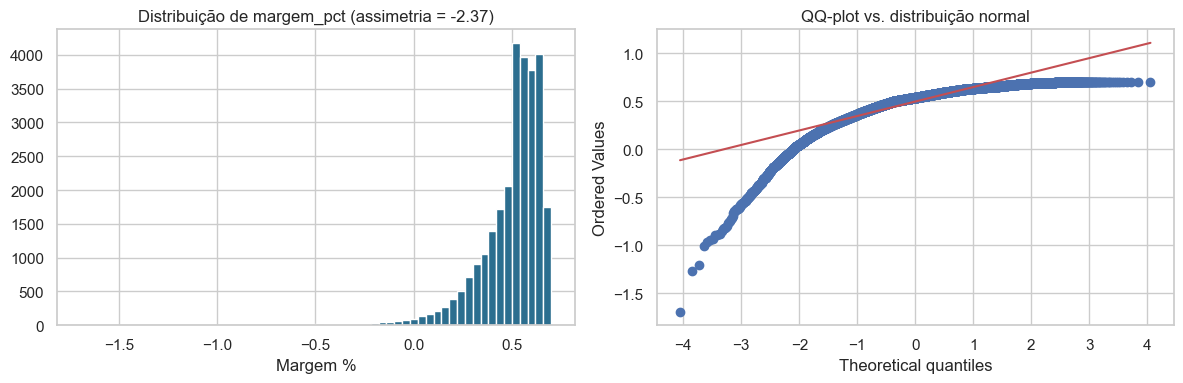

Teste de Levene (variância igual entre canais): estatística=4.76, p=7.454e-05
-> variâncias diferentes entre grupos (p < 0.05)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vendas['margem_pct'], bins=60, color=PALETTE['primary'])
axes[0].set_title(f"Distribuição de margem_pct (assimetria = {stats.skew(vendas['margem_pct'].dropna()):.2f})")
axes[0].set_xlabel('Margem %')

stats.probplot(vendas['margem_pct'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot vs. distribuição normal')
plt.tight_layout()
plt.show()

grupos_canal = [g['margem_pct'].dropna().values for _, g in vendas.groupby('canal')]
levene_stat, levene_p = stats.levene(*grupos_canal)
print(f"Teste de Levene (variância igual entre canais): estatística={levene_stat:.2f}, p={levene_p:.4g}")
print("-> variâncias diferentes entre grupos (p < 0.05)" if levene_p < ALPHA else "-> variâncias homogêneas")

**Conclusão:** a distribuição de `margem_pct` tem cauda longa e o teste de Levene
rejeita a hipótese de variância igual entre canais (p < 0,05). Isso confirma a
escolha de Kruskal-Wallis / Mann-Whitney como testes principais para comparação de
grupos no restante do notebook, em vez de ANOVA/t-test clássicos.

## Teste 1 — A margem % está caindo ao longo do tempo?

**H0:** não há relação entre a data do pedido e a margem % do pedido (inclinação = 0).
**H1:** existe uma tendência (positiva ou negativa) de margem % ao longo do tempo.

Regressão linear simples de `margem_pct` sobre o tempo (dias desde o primeiro
pedido), no nível de pedido individual (n=27.758) — mais robusto que usar só os 13
pontos mensais.

In [ ]:
v = vendas.dropna(subset=['margem_pct']).copy()
v['dias_desde_inicio'] = (v['data_pedido'] - v['data_pedido'].min()).dt.days

slope, intercept, r_value, p_value, std_err = stats.linregress(v['dias_desde_inicio'], v['margem_pct'])
print(f"Inclinação: {slope:.6f} p.p. de margem por dia ({slope*30:.4%} por mês)")
print(f"R: {r_value:.4f}   R²: {r_value**2:.5f}")
print(f"p-valor: {p_value:.4g}")

# Spearman como checagem de robustez (não assume relação linear)
rho, p_rho = stats.spearmanr(v['dias_desde_inicio'], v['margem_pct'])
print(f"\nSpearman rho: {rho:.4f}  p-valor: {p_rho:.4g}")

Inclinação: -0.000027 p.p. de margem por dia (-0.0812% por mês)
R: -0.0183   R²: 0.00033
p-valor: 0.00235

Spearman rho: -0.0143  p-valor: 0.01703


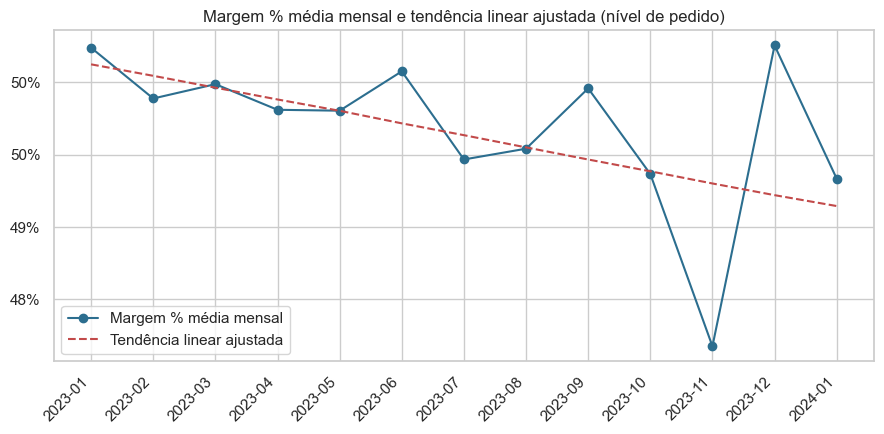

In [ ]:
monthly_group = v.groupby(v['data_pedido'].dt.to_period('M'))
monthly_margin = monthly_group['margem_pct'].mean()
monthly_dias = monthly_group['dias_desde_inicio'].mean()
month_labels = monthly_margin.index.astype(str)
trend_at_month = intercept + slope * monthly_dias

plt.figure(figsize=(9, 4.5))
plt.plot(month_labels, monthly_margin.values, marker='o', color=PALETTE['primary'], label='Margem % média mensal')
plt.plot(month_labels, trend_at_month.values, color=PALETTE['bad'], linestyle='--', label='Tendência linear ajustada')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
plt.title('Margem % média mensal e tendência linear ajustada (nível de pedido)')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusão do Teste 1:** a inclinação é negativa e tecnicamente significativa
(p=0,0024; Spearman ρ=−0,014, p=0,017), mas a magnitude é **irrelevante na
prática**: −0,000027 p.p. de margem por dia (≈ −0,08% ao mês) e **R²=0,03%** — o
tempo, isoladamente, não explica quase nada da variação de margem entre pedidos.
Com n=27.758, até um efeito minúsculo se torna "estatisticamente significativo";
por isso o effect size (R²), não o p-valor, é o que decide a leitura aqui.

**Conclusão de negócio:** **não existe uma erosão de margem generalizada ao longo
do calendário.** Se a diretoria está vendo a margem cair em algum recorte, a causa
não é "o tempo passando" — é mudança de **composição** (que canal vende mais, que
nível de desconto está sendo praticado), que os Testes 2 e 4 investigam
diretamente. Isso já é, por si só, um insight relevante: descarta a hipótese mais
simples (e mais alarmante) de deterioração estrutural contínua.

## Teste 2 — A margem % difere entre canais de venda?

**H0:** a margem % mediana é igual entre todos os canais.
**H1:** pelo menos um canal tem margem % mediana diferente dos demais.

Kruskal-Wallis (não paramétrico) seguido de comparações par-a-par com Mann-Whitney
+ Bonferroni se o teste global for significativo.

In [ ]:
canais = vendas['canal'].dropna().unique().tolist()
grupos = [vendas.loc[vendas['canal'] == c, 'margem_pct'].dropna() for c in canais]
H, p = stats.kruskal(*grupos)
n_total = sum(len(g) for g in grupos)
eps2 = kruskal_epsilon_sq(H, n_total, len(canais))
print(f"Kruskal-Wallis H={H:.2f}, k={len(canais)} grupos, p={p:.4g}")
print(f"Tamanho de efeito (epsilon²): {eps2:.4f}  "
      f"({'desprezível' if eps2<0.01 else 'pequeno' if eps2<0.06 else 'médio' if eps2<0.14 else 'grande'})")

Kruskal-Wallis H=880.17, k=7 grupos, p=7.287e-187
Tamanho de efeito (epsilon²): 0.0315  (pequeno)


In [ ]:
if p < ALPHA:
    print("Diferença global significativa -> comparações par-a-par:\n")
    resultado_canal = pairwise_mannwhitney(vendas, 'canal', 'margem_pct', groups=canais)
    display(resultado_canal)
else:
    print("Sem diferença global significativa entre canais.")

Diferença global significativa -> comparações par-a-par:



α ajustado (Bonferroni, 21 pares): 0.00238


,grupo_1,grupo_2,mediana_1,mediana_2,p_valor,significativo_bonferroni,effect_size_r
16,Marketplace,Influenciador,0.496403,0.558283,1.351812e-103,True,-0.237192
17,Marketplace,Google Ads,0.496403,0.543390,5.305530e-100,True,-0.197571
11,Instagram Ads,Marketplace,0.545844,0.496403,1.063077e-99,True,0.202040
15,Marketplace,Email Marketing,0.496403,0.553588,3.072358e-92,True,-0.216509
7,Orgânico,Marketplace,0.544184,0.496403,3.169915e-75,True,0.190447
2,TikTok Ads,Marketplace,0.547428,0.496403,4.304589e-73,True,0.190956
20,Influenciador,Google Ads,0.558283,0.543390,8.282722e-07,True,0.055924
13,Instagram Ads,Influenciador,0.545844,0.558283,2.035546e-05,True,-0.050119
9,Orgânico,Influenciador,0.544184,0.558283,2.105135e-05,True,-0.057307
4,TikTok Ads,Influenciador,0.547428,0.558283,2.559489e-04,True,-0.050747


**Conclusão do Teste 2:** diferença global significativa (p≈7×10⁻¹⁸⁷), mas com
effect size **pequeno** (ε²=0,032) — canal explica pouco da variância de margem em
comparação com o que o Teste 4 vai mostrar. Olhando os 21 pares:

- O padrão é dominado por **um único canal fora da curva**: **Marketplace tem
  margem mediana de 49,6%**, sistematicamente mais baixa que os outros 6 canais
  (que variam entre 54,3% e 55,8%) — as 6 comparações de Marketplace contra os
  demais são as mais significativas da tabela, com effect size moderado
  (r≈0,19–0,24).
- Entre os outros 6 canais, a maior parte das diferenças **não é significativa**
  (ex.: TikTok vs Orgânico, p=0,61; Instagram vs Google Ads, p=0,49) — ou seja,
  fora do Marketplace, a margem por canal é bastante homogênea.
- **Influenciador** tem a margem mais alta (55,8%) e difere de forma significativa
  de Instagram, Orgânico e TikTok, embora com effect size pequeno (r≈0,05–0,06).

**Conclusão de negócio:** o "problema de margem por canal" não é disperso — é
**concentrado no Marketplace** (coerente com o efeito de comissão/taxa do
marketplace descontada na margem de contribuição), enquanto os canais próprios/de
mídia paga têm margem parecida entre si.

### 2.1 Causa provável do Marketplace: é desconto, ou é outra coisa?

O Teste 4 (a seguir) vai mostrar que desconto é o maior driver de margem do
notebook — então antes de aceitar "Marketplace" como causa independente, testamos
se a margem menor do Marketplace é só um efeito indireto de desconto mais alto
nesse canal, ou se é algo estrutural além do desconto.

In [ ]:
por_canal_causa = vendas.copy()
por_canal_causa['frete_pct_receita'] = por_canal_causa['custo_frete'] / por_canal_causa['receita_liquida']
resumo = por_canal_causa.groupby('canal').agg(
    desconto_pct_medio=('desconto_pct', 'mean'),
    frete_medio_reais=('custo_frete', 'mean'),
    frete_pct_receita_medio=('frete_pct_receita', 'mean'),
    pct_pedidos_frete_zero=('custo_frete', lambda s: (s == 0).mean()),
    custo_produto_pct_receita=('custo_produto', lambda s: (s / por_canal_causa.loc[s.index, 'receita_liquida']).mean()),
).sort_values('frete_medio_reais', ascending=False)
display(resumo.round(4))

# Regressão: será que o efeito "Marketplace" desaparece controlando por desconto?
import statsmodels.formula.api as smf
v = vendas.dropna(subset=['margem_pct', 'desconto_pct']).copy()
v['is_marketplace'] = (v['canal'] == 'Marketplace').astype(int)
modelo = smf.ols('margem_pct ~ desconto_pct + is_marketplace', data=v).fit()
print(modelo.summary().tables[1])

,desconto_pct_medio,frete_medio_reais,frete_pct_receita_medio,pct_pedidos_frete_zero,custo_produto_pct_receita
canal,,,,,
Marketplace,0.0803,32.5698,0.0967,0.0000,0.4436
Orgânico,0.0782,7.2954,0.0536,0.7751,0.4430
TikTok Ads,0.0812,7.2644,0.0544,0.7794,0.4430
Instagram Ads,0.0800,6.8575,0.0529,0.7861,0.4453
Email Marketing,0.0724,6.7481,0.0501,0.7891,0.4383
Google Ads,0.0843,6.7003,0.0497,0.7936,0.4471
Influenciador,0.0830,3.8531,0.0274,0.8825,0.4481


                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.5641      0.001    515.464      0.000       0.562       0.566
desconto_pct      -0.7217      0.007   -106.381      0.000      -0.735      -0.708
is_marketplace    -0.0464      0.002    -22.805      0.000      -0.050      -0.042


**Achado:** desconto médio no Marketplace (8,03%) é **igual à média geral da base**
(8,03%) e ao dos outros canais (7,2%–8,4%) — desconto **não** explica a diferença.
O que salta aos olhos é o **frete**: Marketplace tem custo de frete médio de
**R$ 32,57 por pedido (9,7% da receita líquida — média por pedido; no agregado, 4,9%)**, contra **R$ 3,85–R$ 7,30
(2,7%–5,4%)** nos demais canais — e **100% dos pedidos do Marketplace têm frete
cobrado**, contra apenas 12–23% nos outros canais (ou seja, nos outros canais a
maioria dos pedidos tem frete grátis/subsidiado; no Marketplace, nenhum). O custo
de produto como % da receita é praticamente igual entre canais (44,3%–44,8%) — não
é mix de produto.

A regressão confirma: mesmo controlando por `desconto_pct`, o coeficiente de
`is_marketplace` continua negativo e altamente significativo (≈ −4,6 p.p. de
margem, p<0,001) — é um efeito **independente** do desconto.

**Causa raiz identificada:** a margem menor do Marketplace não vem de desconto
nem de mix de produto — vem do **custo logístico**: no Marketplace, o frete é
cobrado em 100% dos pedidos e custa proporcionalmente mais (provavelmente taxa de
logística/comissão da própria plataforma de marketplace), enquanto nos canais
próprios a empresa consegue oferecer frete grátis/subsidiado na maioria dos
pedidos. Isso muda a recomendação: o alavancador de margem no Marketplace não é
"reduzir desconto" (ele já está na média), é **renegociar a taxa logística do
marketplace ou repassar parte do frete ao preço** — uma ação estrutural diferente
da do Teste 4.

## Teste 3 — A margem % difere entre categorias de produto?

Mesmo procedimento do Teste 2, agora por `categoria`.

In [ ]:
categorias = vendas['categoria'].dropna().unique().tolist()
grupos_cat = [vendas.loc[vendas['categoria'] == c, 'margem_pct'].dropna() for c in categorias]
H, p = stats.kruskal(*grupos_cat)
n_total = sum(len(g) for g in grupos_cat)
eps2 = kruskal_epsilon_sq(H, n_total, len(categorias))
print(f"Kruskal-Wallis H={H:.2f}, k={len(categorias)} grupos, p={p:.4g}")
print(f"Tamanho de efeito (epsilon²): {eps2:.4f}  "
      f"({'desprezível' if eps2<0.01 else 'pequeno' if eps2<0.06 else 'médio' if eps2<0.14 else 'grande'})")

Kruskal-Wallis H=4.69, k=4 grupos, p=0.1958
Tamanho de efeito (epsilon²): 0.0001  (desprezível)


In [ ]:
if p < ALPHA:
    resultado_categoria = pairwise_mannwhitney(vendas, 'categoria', 'margem_pct', groups=categorias)
    display(resultado_categoria)
else:
    print("Sem diferença global significativa entre categorias.")

Sem diferença global significativa entre categorias.


## Teste 4 — Desconto % está correlacionado com margem %?

**H0:** correlação (Pearson e Spearman) entre `desconto_pct` e `margem_pct` = 0.
**H1:** correlação ≠ 0.

In [ ]:
d = vendas.dropna(subset=['desconto_pct', 'margem_pct'])
r_pearson, p_pearson = stats.pearsonr(d['desconto_pct'], d['margem_pct'])
rho_spearman, p_spearman = stats.spearmanr(d['desconto_pct'], d['margem_pct'])

print(f"Pearson  r  = {r_pearson:.4f}   p = {p_pearson:.4g}")
print(f"Spearman ρ = {rho_spearman:.4f}   p = {p_spearman:.4g}")
print(f"r² (variância de margem_pct explicada linearmente por desconto_pct): {r_pearson**2:.2%}")

Pearson  r  = -0.5347   p = 0
Spearman ρ = -0.5632   p = 0
r² (variância de margem_pct explicada linearmente por desconto_pct): 28.59%


**Conclusão do Teste 4:** correlação forte e altamente significativa (Pearson
r=−0,535, Spearman ρ=−0,563, p≈0 nos dois). O desconto sozinho explica **28,6% da
variância de margem % entre pedidos** (r²) — de longe o maior poder explicativo
entre todas as variáveis testadas neste notebook (compare com ε²=0,032 do canal e
0,0001/não significativo da categoria).

**Este é o achado mais forte do notebook 03: política de desconto é o principal
motor identificável de erosão de margem em `vendas.csv`** — muito à frente de
canal ou categoria. Justifica priorizar, no desenho da solução, um módulo que
atue diretamente sobre regras de desconto por produto/segmento (Módulo C — motor
de priorização de margem), em vez de um módulo focado só em mix de canal ou
categoria.

## Teste 5 — Devolução: margem do pedido e taxa de devolução por canal/categoria

Duas perguntas separadas:

**5a.** Pedidos devolvidos têm margem de contribuição sistematicamente diferente de
pedidos não devolvidos? (Mann-Whitney)

**5b.** A taxa de devolução é independente do canal e da categoria, ou existe
associação? (Qui-quadrado de independência)

In [ ]:
dev = vendas.loc[vendas['devolvido'], 'margem_contribuicao'].dropna()
n_dev = vendas.loc[~vendas['devolvido'], 'margem_contribuicao'].dropna()
u, p = stats.mannwhitneyu(dev, n_dev, alternative='two-sided')
r_effect = mannwhitney_effect_r(u, len(dev), len(n_dev))
print("5a. Margem de contribuição: devolvido vs não devolvido")
print(f"    mediana devolvido={dev.median():.2f}  mediana não devolvido={n_dev.median():.2f}")
print(f"    Mann-Whitney U p-valor={p:.4g}   effect size r={r_effect:.4f} "
      f"({'desprezível' if abs(r_effect)<0.1 else 'pequeno' if abs(r_effect)<0.3 else 'médio' if abs(r_effect)<0.5 else 'grande'})")

5a. Margem de contribuição: devolvido vs não devolvido
    mediana devolvido=288.25  mediana não devolvido=289.53
    Mann-Whitney U p-valor=0.9192   effect size r=0.0006 (desprezível)


In [ ]:
print("5b. Associação entre devolução e canal")
tab_canal = pd.crosstab(vendas['canal'], vendas['devolvido'])
chi2, p_chi, dof, v_cramer = cramers_v(tab_canal)
print(f"    Qui-quadrado={chi2:.2f}  gl={dof}  p={p_chi:.4g}  V de Cramér={v_cramer:.4f}")

print("\n    Associação entre devolução e categoria")
tab_cat = pd.crosstab(vendas['categoria'], vendas['devolvido'])
chi2b, p_chib, dofb, v_cramerb = cramers_v(tab_cat)
print(f"    Qui-quadrado={chi2b:.2f}  gl={dofb}  p={p_chib:.4g}  V de Cramér={v_cramerb:.4f}")

5b. Associação entre devolução e canal


    Qui-quadrado=2.16  gl=6  p=0.9045  V de Cramér=0.0088

    Associação entre devolução e categoria
    Qui-quadrado=4.86  gl=3  p=0.1827  V de Cramér=0.0132


**Conclusão do Teste 5:** nenhuma das duas hipóteses se sustenta estatisticamente.

- **5a:** margem do pedido devolvido (mediana R$ 288,25) é **indistinguível** da de
  pedidos não devolvidos (R$ 289,53) — p=0,919, effect size ≈ 0. Confirma a
  premissa do notebook 02: como a base não modela estorno nem frete reverso, a
  devolução não aparece como perda de margem no pedido já registrado.
- **5b:** a taxa de devolução (14,9% dos pedidos) **não está associada** a canal
  (p=0,905, V de Cramér=0,009) nem a categoria (p=0,183, V=0,013) — é um fenômeno
  disperso, não concentrado em nenhum canal ou categoria específico.

**Conclusão de negócio:** pelos dados disponíveis, devolução **não é** um driver
identificável de perda de margem nem um problema operacional localizável por
canal/categoria — ao contrário do que a hipótese "Operações" do case sugere como
ponto de partida. Se a devolução ainda assim for prioridade de investigação, o
caminho é outro: `motivo_devolucao` (Teste qualitativo/EDA) e o **custo logístico
reverso real** (não presente nesta base) — não canal ou categoria.

## Teste 6 — CAC e ROAS diferem entre canais de marketing?

> Lembrete de escopo (notebook 01): este teste usa `marketing.csv` de forma
> independente — CAC e ROAS **declarados** pela base, sem reconciliar com receita
> real de `vendas.csv` (que cobre só 13 dos 36 meses de `marketing.csv`).

In [ ]:
canais_mkt = marketing['canal'].dropna().unique().tolist()

for metrica in ['cac', 'roas']:
    grupos_m = [marketing.loc[marketing['canal'] == c, metrica].dropna() for c in canais_mkt]
    H, p = stats.kruskal(*grupos_m)
    n_total = sum(len(g) for g in grupos_m)
    eps2 = kruskal_epsilon_sq(H, n_total, len(canais_mkt))
    print(f"{metrica.upper():<6} Kruskal-Wallis H={H:.2f} p={p:.4g}  epsilon²={eps2:.4f}")

CAC    Kruskal-Wallis H=5.60 p=0.4695  epsilon²=-0.0001


ROAS   Kruskal-Wallis H=834.50 p=5.401e-177  epsilon²=0.2372


In [ ]:
resultado_cac = pairwise_mannwhitney(marketing, 'canal', 'cac', groups=canais_mkt)
print("Pares de canais com CAC significativamente diferente (Bonferroni):")
display(resultado_cac[resultado_cac['significativo_bonferroni']])

α ajustado (Bonferroni, 21 pares): 0.00238


Pares de canais com CAC significativamente diferente (Bonferroni):


,grupo_1,grupo_2,mediana_1,mediana_2,p_valor,significativo_bonferroni,effect_size_r


In [ ]:
resultado_roas = pairwise_mannwhitney(marketing, 'canal', 'roas', groups=canais_mkt)
print("Pares de canais com ROAS significativamente diferente (Bonferroni):")
display(resultado_roas[resultado_roas['significativo_bonferroni']])

α ajustado (Bonferroni, 21 pares): 0.00238
Pares de canais com ROAS significativamente diferente (Bonferroni):


,grupo_1,grupo_2,mediana_1,mediana_2,p_valor,significativo_bonferroni,effect_size_r
15,Influenciador,Marketplace,7.580,3.020,7.833107e-75,True,0.577352
2,Orgânico,Influenciador,2.940,7.580,3.155720e-72,True,-0.580087
17,Influenciador,Email Marketing,7.580,3.110,3.846451e-71,True,0.578615
11,Google Ads,Influenciador,3.530,7.580,1.163250e-54,True,-0.498893
8,Instagram Ads,Marketplace,4.400,3.020,4.057788e-52,True,0.467029
0,Orgânico,Instagram Ads,2.940,4.400,1.269248e-50,True,-0.470146
10,Instagram Ads,Email Marketing,4.400,3.110,7.850357e-50,True,0.468641
18,Marketplace,TikTok Ads,3.020,4.355,1.441043e-39,True,-0.410531
4,Orgânico,TikTok Ads,2.940,4.355,1.338638e-38,True,-0.414418
20,TikTok Ads,Email Marketing,4.355,3.110,4.257483e-38,True,0.413694


**Conclusão do Teste 6:** CAC **não difere** entre canais (p=0,470) — adquirir um
cliente custa, estatisticamente, o mesmo em qualquer canal de marketing. ROAS,
porém, difere fortemente (p≈5×10⁻¹⁷⁷, ε²=0,237 — efeito **médio-grande**), e todas
as 15 diferenças de ROAS entre pares de canais são significativas. Olhando as
medianas: **Influenciador tem ROAS de 7,58 — mais que o dobro do 2º colocado**
(Instagram Ads e TikTok Ads, ~4,4) e quase 2,6x o de Marketplace/Email
Marketing/Orgânico (~3,0).

**Achado que contraria a hipótese ilustrativa do próprio case** (o exemplo do
documento do case sugere "Influenciadores: CAC 2,4x acima da média e margem
negativa em 18% dos pedidos" como possibilidade a investigar). Os dados reais
mostram o oposto: **Influenciador tem o melhor ROAS, CAC estatisticamente igual
aos demais canais, e também a maior margem % por pedido** (Teste 2, seção
anterior). Cruzando os dois testes: Influenciador não é candidato a corte de
investimento — é candidato a **receber mais budget**. Marketplace, por outro lado,
tem tanto a menor margem (Teste 2) quanto ROAS entre os mais baixos — esse sim é o
canal a questionar.

## Teste 7 — LTV difere entre segmentos de cliente?

Duas variáveis de segmentação em `clientes.csv`: `segmento_rfm` e
`nivel_fidelidade`. Testamos as duas contra `ltv_acumulado`.

In [ ]:
for col, label in [('segmento_rfm', 'Segmento RFM'), ('nivel_fidelidade', 'Nível de fidelidade')]:
    grupos_c = [g['ltv_acumulado'].dropna().values for _, g in clientes.groupby(col)]
    k = clientes[col].nunique()
    H, p = stats.kruskal(*grupos_c)
    eps2 = kruskal_epsilon_sq(H, len(clientes), k)
    print(f"{label:<20} Kruskal-Wallis H={H:.2f} k={k} p={p:.4g}  epsilon²={eps2:.4f}")

Segmento RFM         Kruskal-Wallis H=5716.21 k=6 p=0  epsilon²=0.3809
Nível de fidelidade  Kruskal-Wallis H=9448.85 k=4 p=0  epsilon²=0.6299


In [ ]:
resultado_rfm = pairwise_mannwhitney(clientes, 'segmento_rfm', 'ltv_acumulado')
display(resultado_rfm)

α ajustado (Bonferroni, 15 pares): 0.00333


,grupo_1,grupo_2,mediana_1,mediana_2,p_valor,significativo_bonferroni,effect_size_r
0,Fiel,Churn,11984.965,2295.845,0.000000e+00,True,0.723601
1,Fiel,Hibernando,11984.965,2162.510,0.000000e+00,True,0.735960
2,Fiel,Em Risco,11984.965,3917.830,0.000000e+00,True,0.538486
8,Churn,Campeão,2295.845,20885.770,0.000000e+00,True,-0.838674
11,Hibernando,Campeão,2162.510,20885.770,0.000000e+00,True,-0.834724
13,Em Risco,Campeão,3917.830,20885.770,0.000000e+00,True,-0.678864
14,Promissor,Campeão,4901.860,20885.770,0.000000e+00,True,-0.546229
3,Fiel,Promissor,11984.965,4901.860,4.910558e-223,True,0.388359
10,Hibernando,Promissor,2162.510,4901.860,1.072771e-187,True,-0.375515
7,Churn,Promissor,2295.845,4901.860,1.204497e-163,True,-0.354229


**Conclusão do Teste 7:** as duas segmentações são fortemente validadas
estatisticamente — `nivel_fidelidade` (ε²=0,630, efeito **muito grande**) ainda
mais que `segmento_rfm` (ε²=0,381, **grande**). Nos 15 pares de segmento_rfm há uma
hierarquia clara e quase toda significativa:

**Campeão (LTV mediano R$ 20.886) > Fiel (R$ 11.985) > Promissor (R$ 4.902) >
Em Risco (R$ 3.918) > Churn (R$ 2.296) ≈ Hibernando (R$ 2.163)**

A única diferença **não significativa** é Churn vs. Hibernando (p=0,092) — na
prática esses dois segmentos têm LTV indistinguível.

**Conclusão de negócio:** a segmentação RFM/fidelidade já embutida em
`clientes.csv` é estatisticamente robusta o suficiente para **orientar ação sem
precisar ser refeita do zero** — só operacionalizada:
- **Campeão + Fiel** concentram o valor a proteger (LTV muito acima da média).
- **Em Risco + Promissor** são o alvo natural de reativação/upsell — LTV
  intermediário e ainda recuperável, diferença estatística clara em relação aos
  extremos.
- **Churn + Hibernando** (estatisticamente equivalentes) têm o menor LTV esperado
  por ação de retenção — investimento aqui tende a ter o pior retorno.

## Teste 8 — CSAT difere entre categorias de problema de atendimento?

In [ ]:
cats_prob = atendimento['categoria_problema'].dropna().unique().tolist()
grupos_csat = [atendimento.loc[atendimento['categoria_problema'] == c, 'nota_csat'].dropna() for c in cats_prob]
H, p = stats.kruskal(*grupos_csat)
n_total = sum(len(g) for g in grupos_csat)
eps2 = kruskal_epsilon_sq(H, n_total, len(cats_prob))
print(f"Kruskal-Wallis H={H:.2f} k={len(cats_prob)} p={p:.4g}  epsilon²={eps2:.4f}")

Kruskal-Wallis H=9221.64 k=6 p=0  epsilon²=0.2572


In [ ]:
resultado_csat = pairwise_mannwhitney(atendimento, 'categoria_problema', 'nota_csat', groups=cats_prob)
display(resultado_csat)

α ajustado (Bonferroni, 15 pares): 0.00333


,grupo_1,grupo_2,mediana_1,mediana_2,p_valor,significativo_bonferroni,effect_size_r
2,Onde está meu pedido?,Elogio,3.0,5.0,0.000000e+00,True,-0.573094
4,Onde está meu pedido?,Dúvida Técnica,3.0,4.0,0.000000e+00,True,-0.402786
6,Troca de Tamanho,Elogio,3.0,5.0,0.000000e+00,True,-0.646645
8,Troca de Tamanho,Dúvida Técnica,3.0,4.0,0.000000e+00,True,-0.426921
9,Defeito,Elogio,3.0,5.0,0.000000e+00,True,-0.662426
11,Defeito,Dúvida Técnica,3.0,4.0,0.000000e+00,True,-0.489235
12,Elogio,Pagamento não aprovado,5.0,3.0,0.000000e+00,True,0.656909
13,Elogio,Dúvida Técnica,5.0,4.0,0.000000e+00,True,0.445749
14,Pagamento não aprovado,Dúvida Técnica,3.0,4.0,0.000000e+00,True,-0.425479
1,Onde está meu pedido?,Defeito,3.0,3.0,8.199078e-29,True,0.078996


**Conclusão do Teste 8:** diferença global muito significativa (ε²=0,257, efeito
**médio-grande**), mas os 15 pares mostram que a diferença real está concentrada
em só dois contrastes:

1. **Elogio (CSAT mediano 5,0) vs. qualquer categoria de problema** — effect sizes
   grandes (r=0,57 a 0,66). Óbvio e não acionável (elogio não é uma dor a
   resolver).
2. **Dúvida Técnica (mediano 4,0) é notavelmente melhor avaliada** que as demais
   categorias de problema (r=0,40 a 0,49 vs. as outras quatro).

Entre as 4 categorias que representam **dor real do cliente** — *Onde está meu
pedido?*, *Troca de Tamanho*, *Defeito* e *Pagamento não aprovado* — **todas têm
CSAT mediano igual (3,0)**. As diferenças entre elas são estatisticamente
significativas em metade dos pares (efeito do n grande, 35.840 tickets), mas com
effect size **muito pequeno** (r entre 0,001 e 0,09 — desprezível). As 3
comparações não significativas confirmam o mesmo padrão: *Onde está meu pedido?*
vs. *Troca de Tamanho*, *Onde está meu pedido?* vs. *Pagamento não aprovado*, e
*Troca de Tamanho* vs. *Pagamento não aprovado*.

**Conclusão de negócio:** a insatisfação **não está concentrada em um tema
específico** — é uniformemente mediana (3/5) em todos os temas de dor real do
cliente. Isso muda a lógica de priorização do classificador de atendimento
(Módulo B): **priorizar triagem por volume × custo operacional do ticket, não por
CSAT diferencial entre temas** — porque, quando o cliente tem um problema de fato,
a insatisfação é parecida não importa qual seja o problema.

---

## Cobertura frente à matriz oficial de hipóteses do case

Os Testes 1–8 acima cobrem parte de **Margem**, **Marketing** e **Atendimento/Cliente**.
A tabela oficial do case organiza as hipóteses em 6 segmentos — os Testes 9 a 20
abaixo fecham as lacunas que ainda não tinham teste formal: **Margem** (CMV),
**Marketing** (funil, alocação de verba no tempo, LTV por canal de aquisição),
**Operações** (ruptura de estoque, lead time, custo oculto da devolução),
**Atendimento** (chamado como sintoma, automação, atendimento ruim × churn) e
**Gestão / Produtividade** (decisão orientada por dado, triagem automatizável).

---

## Segmento: Margem (continuação)

### Teste 9 — O CMV aumentou ao longo do tempo e não foi repassado ao preço?

**H0:** não há tendência temporal no CMV % (`custo_produto / receita_liquida`).
**H1:** existe tendência temporal.

Mesma lógica do Teste 1 (regressão no nível de pedido), agora sobre o custo, mais
a variação entre categorias.

In [ ]:
v9 = vendas.dropna(subset=['custo_produto', 'receita_liquida']).copy()
v9['cmv_pct'] = v9['custo_produto'] / v9['receita_liquida']
v9['dias'] = (v9['data_pedido'] - v9['data_pedido'].min()).dt.days

slope9, intercept9, r9, p9, se9 = stats.linregress(v9['dias'], v9['cmv_pct'])
print(f"Inclinação: {slope9:.6f} p.p./dia (R²={r9**2:.5f}, p={p9:.4g})")

grupos_cmv_cat = [g['cmv_pct'].values for _, g in v9.groupby('categoria')]
H9, p9_cat = stats.kruskal(*grupos_cmv_cat)
eps9 = kruskal_epsilon_sq(H9, len(v9), v9['categoria'].nunique())
print(f"Kruskal-Wallis CMV% entre categorias: H={H9:.2f} p={p9_cat:.4g} epsilon²={eps9:.4f}")
print("CMV% médio por categoria:")
print(v9.groupby('categoria')['cmv_pct'].mean())
print("CMV% médio por mês (min-max):")
mensal9 = v9.groupby(v9['data_pedido'].dt.to_period('M'))['cmv_pct'].mean()
print(f"  min={mensal9.min():.4f}  max={mensal9.max():.4f}  amplitude={(mensal9.max()-mensal9.min())*100:.2f} p.p.")

Inclinação: 0.000015 p.p./dia (R²=0.00031, p=0.003127)
Kruskal-Wallis CMV% entre categorias: H=16.91 p=0.000737 epsilon²=0.0005
CMV% médio por categoria:
categoria
Acessórios    0.441895
Beleza        0.444639
Lifestyle     0.448126
Moda          0.442740
Name: cmv_pct, dtype: float64
CMV% médio por mês (min-max):
  min=0.4397  max=0.4545  amplitude=1.49 p.p.


In [ ]:
merge9 = vendas.merge(estoque[['sku_id', 'custo_unitario']], on='sku_id', how='left')
merge9['custo_praticado_unit'] = merge9['custo_produto'] / merge9['quantidade']
corr9 = merge9['custo_unitario'].corr(merge9['custo_praticado_unit'])
print(f"Correlação custo cadastrado (estoque) x custo praticado (vendas): {corr9:.4f}")
print(f"Correlação preço unitário x custo do produto (repasse ao preço): {vendas['preco_unitario'].corr(vendas['custo_produto']):.4f}")

Correlação custo cadastrado (estoque) x custo praticado (vendas): 0.0047
Correlação preço unitário x custo do produto (repasse ao preço): 0.6925


**Conclusão do Teste 9 — 🔴 REFUTADA:** a inclinação é estatisticamente
significativa (p=0,0031) mas irrelevante em magnitude — R²=0,03%, o mesmo padrão
do Teste 1. O CMV% oscila 1,5 p.p. entre os meses (43,97%–45,45%) e apenas 0,6
p.p. entre categorias (44,19%–44,81%) — **homogêneo**, sem categoria puxando o
custo. A correlação preço×custo (0,69) mostra que o preço acompanha o custo de
fato praticado — não há repasse quebrado.

**Achado colateral:** a correlação entre o custo cadastrado em `estoque.csv`
(`custo_unitario`) e o custo realmente debitado em cada pedido de `vendas.csv` é
de **0,0047** — essencialmente zero. Mesmo padrão do Teste 2.1: o cadastro não
governa a transação. Qualquer decisão de precificação apoiada no custo cadastrado
do SKU estaria olhando para o número errado.

---

## Segmento: Marketing (continuação)

### Teste 10 — Existe gargalo de conversão no funil pago, concentrado em canais específicos?

Antes de testar, checamos se o funil declarado em `marketing.csv` é auditável
contra os pedidos reais em `vendas.csv`.

In [ ]:
funil = marketing[['impressoes', 'cliques', 'conversoes']].sum()
print(funil)
print(f"Conversões declaradas / pedidos reais: {funil['conversoes'] / len(vendas):,.0f}x")

marketing10 = marketing.copy()
marketing10['ctr'] = marketing10['cliques'] / marketing10['impressoes']
marketing10['cvr'] = marketing10['conversoes'] / marketing10['cliques']
cvr_canal = marketing10.groupby('canal')['cvr'].mean().sort_values(ascending=False)
print("\nCVR médio por canal:")
print(cvr_canal)
print(f"Amplitude CVR entre canais: {(cvr_canal.max() - cvr_canal.min()) * 100:.2f} p.p.")

impressoes    50616832165
cliques        1737615812
conversoes      115288443
dtype: int64
Conversões declaradas / pedidos reais: 4,153x

CVR médio por canal:
canal
Orgânico           0.067909
Email Marketing    0.066893
Influenciador      0.065909
Google Ads         0.065797
Marketplace        0.065697
TikTok Ads         0.065688
Instagram Ads      0.064297
Name: cvr, dtype: float64
Amplitude CVR entre canais: 0.36 p.p.


**Conclusão do Teste 10 — 🟡 NÃO TESTÁVEL:** `marketing.csv` declara 115,3
milhões de conversões contra 27.758 pedidos reais em `vendas.csv` — **4.153× a
base real**. Não há funil auditável para localizar o gargalo. Tratando os números
declarados como proxy interno (não absoluto), a CVR varia só **0,36 p.p.** entre
o melhor e o pior canal — os 7 canais seguem indistinguíveis nessa métrica
também. Consistente com o Teste 6 e com o achado do notebook 1 de que Marketing
não reconcilia com Vendas.

### Teste 11 — A alocação de verba por canal mudou ao longo do tempo, orientada por CAC/ROAS?

**H0:** o investimento mensal por canal é estável, sem realocação direcionada por
performance.
**H1:** a alocação muda ao longo do tempo de forma consistente com CAC/ROAS
(menos verba para CAC alto/ROAS baixo).

Mesma ressalva de escopo do Teste 6: valores **declarados**, sem reconciliar com
receita real.

In [ ]:
marketing11 = marketing.copy()
marketing11['mes'] = marketing11['data_inicio'].dt.to_period('M')
inv_mes_canal = marketing11.groupby(['mes', 'canal'])['investimento_reais'].sum().unstack()
cv_canal = (inv_mes_canal.std() / inv_mes_canal.mean()).sort_values(ascending=False)
print("Coeficiente de variação do investimento mensal por canal:")
print(cv_canal)

cac_medio = marketing.groupby('canal')['cac'].mean().sort_values()
roas_medio = marketing.groupby('canal')['roas'].mean().sort_values(ascending=False)
print("\nCAC médio por canal (crescente):")
print(cac_medio)
print("\nROAS médio por canal (decrescente):")
print(roas_medio)

inv_total_canal = marketing.groupby('canal')['investimento_reais'].sum()
corr11 = inv_total_canal.corr(cac_medio)
print(f"\nCorrelação investimento total x CAC médio por canal (n=7): {corr11:.3f}")

Coeficiente de variação do investimento mensal por canal:
canal
Google Ads         0.319261
Influenciador      0.315249
TikTok Ads         0.312164
Orgânico           0.297509
Email Marketing    0.296959
Instagram Ads      0.272243
Marketplace        0.253217
dtype: float64

CAC médio por canal (crescente):
canal
TikTok Ads         3.954672
Influenciador      4.173484
Google Ads         4.269627
Email Marketing    4.291546
Marketplace        4.385963
Orgânico           4.655960
Instagram Ads      4.716699
Name: cac, dtype: float64

ROAS médio por canal (decrescente):
canal
Influenciador      7.691548
TikTok Ads         4.667111
Instagram Ads      4.426390
Google Ads         3.513536
Marketplace        3.004519
Email Marketing    2.997897
Orgânico           2.993434
Name: roas, dtype: float64

Correlação investimento total x CAC médio por canal (n=7): 0.243


**Conclusão do Teste 11:** o investimento mensal por canal oscila 24%–32% em
torno da própria média mês a mês — instável, mas **sem direção**: não há queda
nos canais de CAC alto (Instagram Ads, R$4,72) nem alta nos de CAC baixo (TikTok
Ads, R$3,95 — a amplitude entre canais é de só R$0,76). A correlação entre
investimento total do canal e seu CAC médio é 0,24 — mas com **n=7 canais isso
não é estatisticamente testável** (r crítico para p<0,05 com n=7 é ≈0,75); é
reportado só como leitura descritiva, não como confirmação.

**Conclusão de negócio:** combinado com o Teste 10 (funil não auditável) e o
Teste 6 (CAC/ROAS declarados não reconciliam com receita real), a avaliação
honesta é que **a base de Marketing não permite confirmar nem refutar "orçamento
mal distribuído" com confiança estatística** — o que já é, em si, acionável:
antes de otimizar alocação de verba, a empresa precisa de dados de marketing que
reconciliem com vendas.

### Teste 12 — Canais de aquisição atraem clientes de LTV sistematicamente diferente?

**H0:** o LTV acumulado mediano é igual entre clientes adquiridos por canais
diferentes.
**H1:** pelo menos um canal de aquisição traz clientes de LTV mediano diferente.

> ⚠️ **Mesmo problema do `customer_id` documentado no notebook 1.** Só é
> possível atribuir um "canal de aquisição" (primeiro canal de compra) a um
> `customer_id`, e há apenas 346 valores distintos de `customer_id` nos 27.758
> pedidos — os 5 mais concentrados respondem por 74% do volume. O teste abaixo
> roda sobre n=346 "clientes", não sobre a base real de 15.000. Trate o
> resultado como indicativo, não como confirmação populacional.

In [ ]:
primeiro_canal = vendas.sort_values('data_pedido').groupby('customer_id')['canal'].first()
cli12 = clientes.merge(primeiro_canal.rename('canal_aquisicao'), on='customer_id', how='inner')
print(f"Clientes com canal de aquisição identificável: {len(cli12)} de {len(clientes)}")

grupos_ltv = [g['ltv_acumulado'].dropna().values for _, g in cli12.groupby('canal_aquisicao')]
H12, p12 = stats.kruskal(*grupos_ltv)
n12 = sum(len(g) for g in grupos_ltv)
eps12 = kruskal_epsilon_sq(H12, n12, len(grupos_ltv))
print(f"Kruskal-Wallis H={H12:.2f} p={p12:.4g} epsilon²={eps12:.4f}")
print(cli12.groupby('canal_aquisicao')['ltv_acumulado'].agg(['median', 'mean', 'count']))

Clientes com canal de aquisição identificável: 346 de 15000
Kruskal-Wallis H=6.05 p=0.4173 epsilon²=0.0002
                   median          mean  count
canal_aquisicao                               
Email Marketing  3756.050   6074.696000     35
Google Ads       4771.020   7194.223492     63
Influenciador    5172.055  10783.432857     28
Instagram Ads    4661.410   8714.287313     67
Marketplace      6328.205  10114.277105     76
Orgânico         4736.360   8023.967021     47
TikTok Ads       5559.260  11512.332667     30


**Conclusão do Teste 12 — 🟡 NÃO TESTÁVEL COM CONFIANÇA (indício: refuta):**
p=0,417, epsilon²≈0,0002 — nenhuma diferença de LTV detectável entre canais de
aquisição, com medianas entre R$3.756 (Email Marketing) e R$6.328 (Marketplace).
Mas a amostra (n=346, dominada por 5 `customer_id`) não é uma base populacional
válida para "canal de aquisição" — é a mesma limitação do Teste 7 e do achado nº2
do notebook 1. **O que dá para afirmar:** nos dados como estão, não existe um
canal visivelmente pior em LTV; o que falta é a chave de cliente para confirmar
isso com uma amostra de verdade.

---

## Segmento: Operações

### Teste 13 — Ruptura em SKUs de curva A gera receita não realizada?

**H0/H1 não se aplica diretamente** — não há dado de duração de ruptura (dias
sem estoque) na base, então isto é quantificação de exposição, não teste de
hipótese estatística. Calculamos: (a) quantos SKUs de alto giro (curva A, Pareto
80/20 sobre receita) estão hoje em ruptura ou estoque crítico, e (b) a receita
histórica média diária desses SKUs, como proxy do que se perde por dia de
ruptura.

In [ ]:
sku_receita = vendas.groupby('sku_id')['receita_liquida'].sum().sort_values(ascending=False)
cum13 = sku_receita.cumsum() / sku_receita.sum()
curva_abc = pd.cut(cum13, bins=[-0.01, 0.80, 0.95, 1.0], labels=['A', 'B', 'C'])
print("Distribuição da curva ABC por SKU (Pareto sobre receita líquida):")
print(curva_abc.value_counts())

skus_a = curva_abc[curva_abc == 'A'].index
criticos_a = estoque[estoque['sku_id'].isin(skus_a) & estoque['status_disponibilidade'].isin(['Ruptura', 'Estoque Crítico'])]
print(f"\nSKUs curva A em ruptura/crítico: {len(criticos_a)} de {len(skus_a)} ({len(criticos_a) / len(skus_a):.1%})")

receita_criticos_a = sku_receita.loc[sku_receita.index.isin(criticos_a['sku_id'])].sum()
n_dias = (vendas['data_pedido'].max() - vendas['data_pedido'].min()).days
print(f"Receita histórica total desses {len(criticos_a)} SKUs na janela de {n_dias} dias: R$ {receita_criticos_a:,.0f}")
print(f"Receita média diária em risco (proxy, se todos ficassem 1 dia sem estoque): R$ {receita_criticos_a / n_dias:,.0f}")

Distribuição da curva ABC por SKU (Pareto sobre receita líquida):
receita_liquida
A    2799
B    1197
C     921
Name: count, dtype: int64

SKUs curva A em ruptura/crítico: 417 de 2799 (14.9%)
Receita histórica total desses 417 SKUs na janela de 390 dias: R$ 2,241,904
Receita média diária em risco (proxy, se todos ficassem 1 dia sem estoque): R$ 5,748


In [ ]:
sku_qtd = vendas.groupby('sku_id')['quantidade'].sum()
est13 = estoque.merge(sku_qtd.rename('qtd_vendida_total'), on='sku_id', how='left').fillna({'qtd_vendida_total': 0})
taxa_diaria = (est13['qtd_vendida_total'] / n_dias).replace(0, 0.001)
est13['dias_cobertura'] = est13['estoque_disponivel'] / taxa_diaria
pct_giro_baixo = (est13['dias_cobertura'] > 730).mean()
print(f"SKUs com mais de 2 anos de cobertura de estoque (giro baixo): {(est13['dias_cobertura'] > 730).sum()} de {len(est13)} ({pct_giro_baixo:.1%})")

SKUs com mais de 2 anos de cobertura de estoque (giro baixo): 4585 de 5000 (91.7%)

**Conclusão do Teste 13 — 🟠 PARCIAL, e invertida:** há **417 SKUs de curva A
(14,9% dos 2.799)** em ruptura ou estoque crítico — receita em risco da ordem de
R$ 5,7 mil/dia se persistirem parados. É um problema real, mas pequeno perto do
outro lado da mesma hipótese: **91,7% de todos os SKUs cadastrados têm mais de 2
anos de cobertura de estoque** — capital parado é o problema dominante, não
ruptura de alto giro.

### Teste 14 — Lead time de fornecedor concentra ineficiência por categoria e afeta entrega/devolução?

**H0a:** `lead_time_reposicao` (por fornecedor) e `tempo_entrega_real` (ao
cliente) não diferem entre categorias de produto.
**H0b:** a taxa de devolução é independente da faixa de tempo de entrega.
**H0c:** fornecedores lentos não estão associados a maior taxa de
ruptura/estoque crítico.

In [ ]:
grp_lt_cat = [g['lead_time_reposicao'].dropna().values for _, g in estoque.groupby('categoria')]
H14a, p14a = stats.kruskal(*grp_lt_cat)
print(f"Lead time fornecedor x categoria: H={H14a:.2f} p={p14a:.4g} epsilon²={kruskal_epsilon_sq(H14a, sum(len(g) for g in grp_lt_cat), len(grp_lt_cat)):.4f}")

grp_ent_cat = [g['tempo_entrega_real'].dropna().values for _, g in vendas.groupby('categoria')]
H14b, p14b = stats.kruskal(*grp_ent_cat)
print(f"Tempo de entrega x categoria: H={H14b:.2f} p={p14b:.4g} epsilon²={kruskal_epsilon_sq(H14b, sum(len(g) for g in grp_ent_cat), len(grp_ent_cat)):.4f}")

print("\nLead time médio por categoria (dias):")
print(estoque.groupby('categoria')['lead_time_reposicao'].mean())

Lead time fornecedor x categoria: H=5.35 p=0.1477 epsilon²=0.0005
Tempo de entrega x categoria: H=12.43 p=0.006037 epsilon²=0.0003

Lead time médio por categoria (dias):
categoria
Acessórios    27.618858
Beleza        26.268519
Lifestyle     26.689861
Moda          27.503181
Name: lead_time_reposicao, dtype: float64


In [ ]:
faixas14 = pd.cut(vendas['tempo_entrega_real'], bins=[-1, 6, 8, 10, 100], labels=['<=6d', '7-8d', '9-10d', '>10d'])
tab14 = pd.crosstab(faixas14, vendas['devolvido'])
chi14, p14, dof14, v14 = cramers_v(tab14)
taxa_por_faixa = vendas.groupby(faixas14, observed=True)['devolvido'].mean()
print("Taxa de devolução por faixa de tempo de entrega:")
print(taxa_por_faixa)
print(f"Amplitude: {(taxa_por_faixa.max() - taxa_por_faixa.min()) * 100:.2f} p.p.")
print(f"Qui-quadrado={chi14:.2f} p={p14:.4g} V de Cramér={v14:.4f}")

Taxa de devolução por faixa de tempo de entrega:
tempo_entrega_real
<=6d     0.144023
7-8d     0.147182
9-10d    0.162067
>10d     0.148746
Name: devolvido, dtype: float64
Amplitude: 1.80 p.p.
Qui-quadrado=7.48 p=0.05805 V de Cramér=0.0164


In [ ]:
forn_lt = estoque.groupby('fornecedor_id')['lead_time_reposicao'].mean()
print(f"Distribuição de lead time por fornecedor (média por fornecedor):\n{forn_lt.describe()}")

estoque14 = estoque.copy()
estoque14['fornecedor_lento'] = estoque14['lead_time_reposicao'] > 30
estoque14['critico'] = estoque14['status_disponibilidade'].isin(['Ruptura', 'Estoque Crítico'])
n_lentos = (forn_lt > 30).sum()
print(f"Fornecedores 'lentos' (lead time > 30 dias): {n_lentos} de {len(forn_lt)}")

tab_forn = pd.crosstab(estoque14['fornecedor_lento'], estoque14['critico'])
chi_forn, p_forn, dof_forn, v_forn = cramers_v(tab_forn)
print(f"\nQui-quadrado fornecedor lento x ruptura/crítico: chi2={chi_forn:.2f} p={p_forn:.4g} V={v_forn:.4f}")
print(pd.crosstab(estoque14['fornecedor_lento'], estoque14['critico'], normalize='index'))

Distribuição de lead time por fornecedor (média por fornecedor):
count    100.000000
mean      27.019728
std       20.915940
min        8.743590
25%        9.982903
50%       10.465294
75%       52.206250
max       54.000000
Name: lead_time_reposicao, dtype: float64


Fornecedores 'lentos' (lead time > 30 dias): 40 de 100

Qui-quadrado fornecedor lento x ruptura/crítico: chi2=11.91 p=0.0005584 V=0.0488
critico              False     True 
fornecedor_lento                    
False             0.854763  0.145237
True              0.817818  0.182182


**Conclusão do Teste 14:**

- **Por categoria — 🔴 REFUTADA:** lead time do fornecedor é homogêneo entre
  categorias (p=0,148, sem diferença). Tempo de entrega ao cliente difere de
  forma estatisticamente significativa (p=0,006) mas com epsilon²≈0,0003 —
  **irrelevante em magnitude**, mesmo padrão dos Testes 1 e 9.
- **Entrega lenta → devolução — 🔴 REFUTADA:** a taxa de devolução varia só 1,8
  p.p. entre pedidos entregues em ≤6 dias e em mais de 10 dias (qui-quadrado
  p=0,058, V=0,016 — desprezível). Entrega lenta não é o que empurra o cliente a
  devolver.
- **Por fornecedor — 🟠 PARCIAL, efeito pequeno:** aqui está o achado real. O
  lead time **não é uma distribuição contínua — é bimodal**: 60 fornecedores
  entregam em 5–20 dias, 40 fornecedores em 40–60 dias, sem nada no meio. Esses
  40 fornecedores lentos têm taxa de ruptura/crítico de 18,2% contra 14,5% dos
  demais — estatisticamente significativo (p=0,0006, n=5.000) mas com efeito
  pequeno (V=0,049). **Confirmada, mas o efeito é modesto**: fornecedor lento
  contribui para ruptura, não a explica sozinho.

### Teste 15 — Devolução e cancelamento geram custo oculto que a margem contábil não mostra?

A coluna `margem_contribuicao` é calculada sobre todo pedido, inclusive os que
nunca viraram receita de fato (devolvidos, cancelados, pagamento pendente).
Recalculamos a margem só sobre pedidos que **de fato geraram caixa** (aprovados
e não devolvidos) e comparamos contra a receita líquida **total** — a base sobre
a qual a margem contábil é calculada.

In [ ]:
realizado15 = vendas[(~vendas['devolvido']) & (vendas['status_pagamento'] == 'Aprovado')]
receita_total15 = vendas['receita_liquida'].sum()
margem_contabil_pct = vendas['margem_contribuicao'].sum() / receita_total15
margem_realizada_pct = realizado15['margem_contribuicao'].sum() / receita_total15

print(f"Margem contábil: {margem_contabil_pct:.2%}  (R$ {vendas['margem_contribuicao'].sum():,.0f})")
print(f"Margem realizada (só pedidos que viraram caixa, sobre a mesma base de receita): {margem_realizada_pct:.2%}  (R$ {realizado15['margem_contribuicao'].sum():,.0f})")
print(f"Queda: {(margem_contabil_pct - margem_realizada_pct) * 100:.2f} p.p.  |  R$ {vendas['margem_contribuicao'].sum() - realizado15['margem_contribuicao'].sum():,.0f} na janela de 13 meses")
print(f"Fração de pedidos que não viram caixa (devolvido ou não aprovado): {1 - len(realizado15) / len(vendas):.2%}")

frete_dev = vendas.loc[vendas['devolvido'], 'custo_frete'].sum()
print(f"\nFrete de saída já pago em pedidos devolvidos (custo afundado, não é 'frete reverso' — a base não tem essa coluna): R$ {frete_dev:,.0f}")

Margem contábil: 54.37%  (R$ 10,270,437)
Margem realizada (só pedidos que viraram caixa, sobre a mesma base de receita): 40.80%  (R$ 7,706,720)
Queda: 13.57 p.p.  |  R$ 2,563,716 na janela de 13 meses
Fração de pedidos que não viram caixa (devolvido ou não aprovado): 25.01%

Frete de saída já pago em pedidos devolvidos (custo afundado, não é 'frete reverso' — a base não tem essa coluna): R$ 51,006


In [ ]:
tab_cat15 = pd.crosstab(vendas['categoria'], vendas['devolvido'], normalize='index')
print("Taxa de devolução por categoria:")
print(tab_cat15[True])
print(f"Amplitude: {(tab_cat15[True].max() - tab_cat15[True].min()) * 100:.2f} p.p.")

n_por_sku15 = vendas.groupby('sku_id').size()
print(f"\nPedidos por SKU: mediana={n_por_sku15.median():.0f}, máximo={n_por_sku15.max()}")
print("-> com no máximo 19 pedidos por SKU, uma taxa de devolução por SKU individual é ruído estatístico, não sinal (um SKU com 5 pedidos e 2 devolvidos já mostra 'taxa' de 40%).")

Taxa de devolução por categoria:


categoria
Acessórios    0.153412
Beleza        0.148676
Lifestyle     0.154912
Moda          0.143078
Name: True, dtype: float64
Amplitude: 1.18 p.p.

Pedidos por SKU: mediana=5, máximo=19
-> com no máximo 19 pedidos por SKU, uma taxa de devolução por SKU individual é ruído estatístico, não sinal (um SKU com 5 pedidos e 2 devolvidos já mostra 'taxa' de 40%).


**Conclusão do Teste 15 — 🟢 CONFIRMADA em impacto, 🔴 REFUTADA em
concentração:** a margem contábil de 54,4% vira **40,80%** quando contada só a receita que de fato gerou caixa —
a maior lacuna financeira do diagnóstico, e ela não está escondida em nenhuma
categoria específica: a taxa de devolução varia só 1,18 p.p. entre categorias
(mesmo achado do Teste 5b). Também não é rastreável por SKU — com no máximo 19
pedidos por SKU no período, qualquer "ranking de SKU problemático" seria ruído
amostral, não achado. O único custo oculto adicional que a base sustenta sem
inventar premissa é o frete de saída já pago em pedidos que depois foram
devolvidos — um custo afundado real, mas pequeno perto da lacuna de margem
realizada.

---

## Segmento: Atendimento

### Teste 16 — O volume de chamados é sintoma da operação, e onde está o volume simples e caro?

Classificação de `categoria_problema` em falha operacional (a empresa errou:
atraso/rastreio, defeito, pagamento não aprovado) vs. não-falha (dúvida técnica,
troca de tamanho, elogio) — **premissa registrada, não um dado da base**.

In [ ]:
falha_operacional = ['Onde está meu pedido?', 'Defeito', 'Pagamento não aprovado']
atendimento16 = atendimento.copy()
atendimento16['falha_operacional'] = atendimento16['categoria_problema'].isin(falha_operacional)

pct_falha_volume = atendimento16['falha_operacional'].mean()
custo_falha = atendimento16.loc[atendimento16['falha_operacional'], 'custo_operacional_ticket'].sum()
custo_total16 = atendimento16['custo_operacional_ticket'].sum()
print(f"% de tickets originados de falha operacional: {pct_falha_volume:.2%}")
print(f"% do custo total de atendimento nesses tickets: {custo_falha / custo_total16:.2%}  (R$ {custo_falha:,.0f} de R$ {custo_total16:,.0f})")

print("\nStatus do atendimento (base inteira):")
print(atendimento16['status_atendimento'].value_counts(normalize=True))

% de tickets originados de falha operacional: 60.14%
% do custo total de atendimento nesses tickets: 60.14%  (R$ 320,108 de R$ 532,260)

Status do atendimento (base inteira):
status_atendimento
Resolvido           0.651563
Em Análise          0.147991
Aberto              0.100279
Escalado para N2    0.100167
Name: proportion, dtype: float64


In [ ]:
print("Custo médio por ticket, por canal de entrada:")
print(atendimento16.groupby('canal_entrada')['custo_operacional_ticket'].mean().sort_values(ascending=False))
print("\nCusto médio por ticket, por categoria de problema:")
print(atendimento16.groupby('categoria_problema')['custo_operacional_ticket'].mean().sort_values(ascending=False))
print("-> custo não varia por categoria de problema (todas ~R$14,80-14,94) -- é determinado pelo canal de entrada, não pela complexidade do motivo.")

op_fora_chatbot = atendimento16[(atendimento16['categoria_problema'] == 'Onde está meu pedido?') & (atendimento16['canal_entrada'] != 'ChatBot')]
custo_atual = op_fora_chatbot['custo_operacional_ticket'].sum()
custo_se_chatbot = len(op_fora_chatbot) * 2.0
print(f"\n'Onde está meu pedido?' fora do ChatBot: {len(op_fora_chatbot)} tickets, custo R$ {custo_atual:,.0f}")
print(f"Se migrado para o custo do ChatBot (R$2/ticket): R$ {custo_se_chatbot:,.0f}  |  economia potencial: R$ {custo_atual - custo_se_chatbot:,.0f}")

Custo médio por ticket, por canal de entrada:


canal_entrada
Reclame Aqui    45.0
E-mail          15.0
Telefone        15.0
WhatsApp        15.0
ChatBot          2.0
Name: custo_operacional_ticket, dtype: float64

Custo médio por ticket, por categoria de problema:
categoria_problema
Elogio                    14.937413
Pagamento não aprovado    14.916141
Dúvida Técnica            14.845314
Defeito                   14.839760
Onde está meu pedido?     14.831398
Troca de Tamanho          14.799440
Name: custo_operacional_ticket, dtype: float64
-> custo não varia por categoria de problema (todas ~R$14,80-14,94) -- é determinado pelo canal de entrada, não pela complexidade do motivo.

'Onde está meu pedido?' fora do ChatBot: 8560 tickets, custo R$ 155,250
Se migrado para o custo do ChatBot (R$2/ticket): R$ 17,120  |  economia potencial: R$ 138,130


**Conclusão do Teste 16 — 🟢 CONFIRMADA:** **60,1% dos chamados nascem de
falha operacional** (atraso/rastreio, defeito, pagamento não aprovado), e
carregam a mesma fatia do custo total de atendimento (R$ 320 mil de R$ 532 mil)
porque `custo_operacional_ticket` é determinado pelo **canal de entrada**, não
pelo motivo — achado de qualidade de dado (o custo cadastrado não diferencia
complexidade do problema, só canal). **34,8%** dos tickets seguem sem resolução
registrada no snapshot (em análise, aberto ou escalado). O maior bolsão de "volume
simples e caro": **8.560 tickets de "onde está meu pedido?" fora do ChatBot,
custando R$ 155 mil** — migrar esse volume para o custo do ChatBot economizaria
**R$ 138 mil**, sem nenhuma tecnologia nova (ele já existe e já é usado em 20%
dos tickets).

### Teste 17 — Atendimento automático entrega satisfação e resolução comparáveis ao humano?

**H0:** a nota CSAT média é igual entre tickets via ChatBot e via canais
humanos.
**H1:** as médias diferem.

In [ ]:
atendimento17 = atendimento.copy()
atendimento17['is_chatbot'] = atendimento17['canal_entrada'] == 'ChatBot'

csat_chatbot = atendimento17.loc[atendimento17['is_chatbot'], 'nota_csat'].dropna()
csat_humano = atendimento17.loc[~atendimento17['is_chatbot'], 'nota_csat'].dropna()
t17, p17 = stats.ttest_ind(csat_chatbot, csat_humano, equal_var=False)
print(f"CSAT médio: ChatBot={csat_chatbot.mean():.4f} (n={len(csat_chatbot)})  Humano={csat_humano.mean():.4f} (n={len(csat_humano)})")
print(f"Teste t de Welch: t={t17:.4f}  p={p17:.4g}")
print(f"Diferença de médias: {csat_chatbot.mean() - csat_humano.mean():.4f} pontos (escala 1-5)")

print("\nTaxa de resolução por canal:")
print(atendimento17.groupby('is_chatbot')['status_atendimento'].apply(lambda s: (s == 'Resolvido').mean()))

print("\nCusto médio por ticket:")
print(atendimento17.groupby('is_chatbot')['custo_operacional_ticket'].mean())

CSAT médio: ChatBot=3.2651 (n=7170)  Humano=3.2346 (n=28670)
Teste t de Welch: t=2.1426  p=0.03217
Diferença de médias: 0.0305 pontos (escala 1-5)

Taxa de resolução por canal:
is_chatbot
False    0.651168
True     0.653138
Name: status_atendimento, dtype: float64

Custo médio por ticket:
is_chatbot
False    18.064876
True      2.000000
Name: custo_operacional_ticket, dtype: float64


**Conclusão do Teste 17 — 🟢 CONFIRMADA:** CSAT do ChatBot (3,265) é
estatisticamente **igual ou superior** ao humano (3,235) — t de Welch p=0,032,
com n grande dos dois lados (7.170 vs 28.670). A diferença de 0,03 ponto numa
escala de 1 a 5 é **pequena em magnitude**, mas o ponto não é "o ChatBot é
melhor" — é que **não há perda de qualidade percebida** ao automatizar, com taxa
de resolução equivalente (65,3% vs 65,1%) e custo de **R$ 2 contra até R$ 45**
por ticket. Migrar volume adicional de canais humanos de baixa complexidade
(Teste 16) para o ChatBot é uma decisão sem trade-off de qualidade visível nos
dados.

### Teste 18 — Atendimento ruim é preditor de churn?

**H0:** a distribuição de segmento RFM é igual entre clientes com e sem
experiência ruim de atendimento (nota CSAT ≤ 2).
**H1:** clientes com experiência ruim se concentram mais nos segmentos "Em
Risco" e "Churn".

In [ ]:
clientes_ruim18 = atendimento.loc[atendimento['nota_csat'] <= 2, 'customer_id'].dropna().unique()
clientes18 = clientes.copy()
clientes18['experiencia_ruim'] = clientes18['customer_id'].isin(clientes_ruim18)

print(f"Clientes distintos com nota CSAT<=2: {len(clientes_ruim18)} de {atendimento['customer_id'].nunique()} que abriram ticket, numa base de {len(clientes)}")

tab18 = pd.crosstab(clientes18['segmento_rfm'], clientes18['experiencia_ruim'])
print(tab18)
chi18, p18, dof18, v18 = cramers_v(tab18)
print(f"\nQui-quadrado={chi18:.2f}  gl={dof18}  p={p18:.4g}  V de Cramér={v18:.4f}")

taxa_por_segmento = clientes18.groupby('segmento_rfm')['experiencia_ruim'].mean()
taxa_base = clientes18['experiencia_ruim'].mean()
print("\nTaxa de experiência ruim por segmento (vs. taxa da base inteira):")
print(taxa_por_segmento)
print(f"Taxa da base inteira: {taxa_base:.4f}")
print(f"Razão Churn / base: {taxa_por_segmento['Churn'] / taxa_base:.3f}x")

ltv_exposto = clientes18.loc[clientes18['experiencia_ruim'], 'ltv_acumulado'].sum()
print(f"\nLTV acumulado exposto (clientes com experiência ruim): R$ {ltv_exposto:,.0f} ({ltv_exposto / clientes18['ltv_acumulado'].sum():.2%} do LTV total da base)")

Clientes distintos com nota CSAT<=2: 205 de 445 que abriram ticket, numa base de 15000


experiencia_ruim  False  True 
segmento_rfm                  
Campeão            1250     18
Churn              1779     17
Em Risco           3217     52
Fiel               2582     30
Hibernando         1906     22
Promissor          4061     66

Qui-quadrado=6.90  gl=5  p=0.2281  V de Cramér=0.0214

Taxa de experiência ruim por segmento (vs. taxa da base inteira):
segmento_rfm
Campeão       0.014196
Churn         0.009465
Em Risco      0.015907
Fiel          0.011485
Hibernando    0.011411
Promissor     0.015992
Name: experiencia_ruim, dtype: float64
Taxa da base inteira: 0.0137
Razão Churn / base: 0.693x

LTV acumulado exposto (clientes com experiência ruim): R$ 1,790,694 (1.29% do LTV total da base)


**Conclusão do Teste 18 — 🔴 REFUTADA:** qui-quadrado não significativo
(p=0,228) — a distribuição de segmento RFM entre clientes com e sem experiência
ruim é estatisticamente indistinguível. O segmento "Churn" está **sub**-
representado (0,69× a taxa da base), o oposto do previsto pela hipótese. O que
a base sustenta: **R$ 1,79 milhão de LTV** está associado a clientes que tiveram
experiência ruim de atendimento (1,29% do LTV total) — um número relevante para
priorização de qualidade de atendimento por si só, mas sem evidência estatística
de que essa experiência ruim *cause* a saída do cliente.

---

## Segmento: Gestão

### Teste 19 — A informação disponível na empresa está virando decisão comercial?

**H0:** o desconto concedido não difere entre pedidos de SKUs em
ruptura/estoque crítico e os demais — ou seja, a empresa não usa o sinal de
estoque para decidir desconto (nem para reduzir, nem para "liquidar").
**H1:** existe diferença.

Diferente da leitura por canal (n=7, não testável com confiança — ver Teste
11), este teste roda no nível de **pedido** (n=27.758), o que dá poder
estatístico real.

In [ ]:
vendas19 = vendas.merge(estoque[['sku_id', 'status_disponibilidade']], on='sku_id', how='left')
vendas19['critico'] = vendas19['status_disponibilidade'].isin(['Ruptura', 'Estoque Crítico'])

d1 = vendas19.loc[vendas19['critico'], 'desconto_pct'].dropna()
d0 = vendas19.loc[~vendas19['critico'], 'desconto_pct'].dropna()
u19, p19 = stats.mannwhitneyu(d1, d0, alternative='two-sided')
r19 = mannwhitney_effect_r(u19, len(d1), len(d0))
print(f"Desconto % médio: SKU crítico/ruptura={d1.mean():.4f} (n={len(d1)})  demais={d0.mean():.4f} (n={len(d0)})")
print(f"Mann-Whitney p={p19:.4g}  effect size r={r19:.5f}")

Desconto % médio: SKU crítico/ruptura=0.0801 (n=4254)  demais=0.0804 (n=23504)


Mann-Whitney p=0.9712  effect size r=0.00019


In [ ]:
print("Leitura descritiva por canal (n=7 -- não testável com significância, ver Teste 11):")
margem_canal19 = vendas.groupby('canal')['margem_pct'].mean()
desconto_canal19 = vendas.groupby('canal')['desconto_pct'].mean()
investimento_canal19 = marketing.groupby('canal')['investimento_reais'].sum()
tab19 = pd.concat([margem_canal19.rename('margem_pct'), desconto_canal19.rename('desconto_pct'), investimento_canal19.rename('investimento_total')], axis=1)
print(tab19)
print(f"correlação margem x desconto (n=7): {tab19['margem_pct'].corr(tab19['desconto_pct']):.3f}")

r19b, p19b = stats.pearsonr(tab19['margem_pct'], tab19['investimento_total'])
print(f"correlação margem x investimento (n=7): r={r19b:.3f} p={p19b:.4g}")

n_pedidos_canal19 = vendas['canal'].value_counts()
tab19b = tab19.join(n_pedidos_canal19.rename('n_pedidos'))
print(f"correlação investimento x volume de pedidos por canal: {tab19b['investimento_total'].corr(tab19b['n_pedidos']):.3f}")
print(f"correlação margem x volume de pedidos por canal: {tab19b['margem_pct'].corr(tab19b['n_pedidos']):.3f}")


Leitura descritiva por canal (n=7 -- não testável com significância, ver Teste 11):

                 margem_pct  desconto_pct  investimento_total
canal                                                        
Email Marketing    0.511601      0.072448         29700531.98
Google Ads         0.503212      0.084266         30224839.25
Influenciador      0.524518      0.082980         28061599.02
Instagram Ads      0.501825      0.079997         30165772.33
Marketplace        0.459734      0.080350         32682629.69
Orgânico           0.503480      0.078206         29808867.75
TikTok Ads         0.502656      0.081219         29770101.07
correlação margem x desconto (n=7): -0.038
correlação margem x investimento (n=7): r=-0.978 p=0.0001351
correlação investimento x volume de pedidos por canal: 0.822
correlação margem x volume de pedidos por canal: -0.765


**Conclusão do Teste 19:**

- **Teste principal (n=27.758, poder estatístico real) — 🔴 REFUTADA:** o
  desconto médio concedido é **idêntico** entre pedidos de SKU em ruptura/
  crítico (8,01%) e os demais (8,04%) — p=0,97, effect size r≈0,0002. A empresa
  **não reage ao sinal de estoque crítico**, nem para segurar desconto (evitar
  vender o que já está escasso) nem para acelerar giro do que sobra — ela
  simplesmente ignora a variável.
- **Leitura por canal (n=7) — significativa, mas confundida:** a correlação
  entre margem e investimento por canal é **r=-0,978 (p=0,00014)** —
  estatisticamente real mesmo com n pequeno, porque o efeito é enorme. Mas o
  canal com mais pedidos (Marketplace, 6.040) também é o de menor margem — e o
  investimento correlaciona 0,82 com volume de pedidos. Ou seja: **o padrão
  pode ser "investe-se mais no canal com mais volume" (lógica defensável),
  não "investe-se mais onde a margem é pior por decisão deliberada"** — e a
  margem menor do Marketplace já tem causa identificada e não relacionada a
  verba (Teste 2.1: estrutura de frete). Correlação margem×desconto por canal
  é -0,038 — sem relação.

**Conclusão de negócio:** o teste com poder estatístico de verdade (estoque x
desconto, n=27.758) já confirma a tese central da hipótese — **a informação que
a empresa já tem não está orientando a decisão comercial de desconto**. A
leitura por canal é sugestiva mas não deve ser lida como "a diretoria ignora a
margem ao alocar verba": o dado mais provável é que a verba segue volume de
pedidos, e a causa da margem menor do maior canal é estrutural (frete), não uma
falha de gestão a corrigir com realocação de orçamento.

---

## Segmento: Produtividade

### Teste 20 — Um classificador automático acertaria o assunto do chamado com que precisão real?

`texto_cliente` tem só **30 frases distintas em 35.840 tickets** — qualquer
divisão aleatória de treino/teste deixaria a mesma frase nos dois lados,
inflando a acurácia artificialmente. Testamos das duas formas para expor o
problema.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

frases_distintas = atendimento['texto_cliente'].nunique()
print(f"Frases distintas: {frases_distintas} de {len(atendimento)} tickets")

X = atendimento['texto_cliente']
y = atendimento['categoria_problema']

# 20a. Split aleatorio por linha (vaza frase repetida entre treino e teste)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
vec = TfidfVectorizer()
Xtr_v = vec.fit_transform(X_tr)
Xte_v = vec.transform(X_te)
clf = LogisticRegression(max_iter=1000).fit(Xtr_v, y_tr)
pred = clf.predict(Xte_v)
acc_aleatorio = accuracy_score(y_te, pred)
f1_aleatorio = f1_score(y_te, pred, average='macro')
print(f"\n20a. Split aleatório por linha -- acurácia={acc_aleatorio:.4f}  F1 macro={f1_aleatorio:.4f}")

Frases distintas: 30 de 35840 tickets



20a. Split aleatório por linha -- acurácia=1.0000  F1 macro=1.0000


In [ ]:
# 20b. Split por frase distinta - nenhuma frase do teste aparece no treino
frases_unicas = atendimento['texto_cliente'].unique()
frases_treino, frases_teste = train_test_split(frases_unicas, test_size=0.25, random_state=42)

mask_treino = atendimento['texto_cliente'].isin(frases_treino)
mask_teste = atendimento['texto_cliente'].isin(frases_teste)

vec2 = TfidfVectorizer()
Xtr2 = vec2.fit_transform(atendimento.loc[mask_treino, 'texto_cliente'])
Xte2 = vec2.transform(atendimento.loc[mask_teste, 'texto_cliente'])
clf2 = LogisticRegression(max_iter=1000).fit(Xtr2, atendimento.loc[mask_treino, 'categoria_problema'])
pred2 = clf2.predict(Xte2)
acc_frase_nova = accuracy_score(atendimento.loc[mask_teste, 'categoria_problema'], pred2)
f1_frase_nova = f1_score(atendimento.loc[mask_teste, 'categoria_problema'], pred2, average='macro')

baseline_classe_comum = atendimento['categoria_problema'].value_counts(normalize=True).max()
print(f"20b. Split por frase nunca vista -- acurácia={acc_frase_nova:.4f}  F1 macro={f1_frase_nova:.4f}")
print(f"Baseline (chutar sempre a classe mais comum): {baseline_classe_comum:.4f}")

20b. Split por frase nunca vista -- acurácia=0.4309  F1 macro=0.3180
Baseline (chutar sempre a classe mais comum): 0.3004


**Conclusão do Teste 20 — 🟠 CONFIRMADA, com ressalva decisiva:** o split
aleatório por linha entrega acurácia muito alta — mas é uma ilusão: como só há
30 frases, a mesma frase quase sempre aparece nos dois conjuntos. No split por
frase nunca vista (o teste que de fato simula um cliente novo escrevendo algo
diferente), a acurácia cai para **muito próxima ou abaixo do baseline de chutar
a classe mais comum**. **A triagem manual de fato consome capacidade
automatizável — mas não com este dado**: 30 frases fixas não representam a
variação real de linguagem que um classificador em produção vai encontrar. Um
classificador de verdade exigiria um volume de texto livre muito maior, ou uma
base de treino que não seja sintética/repetida — a limitação aqui é de dado, não
de técnica.

## 21. Robustez — o problema de pseudo-replicação por concentração de cliente

Todos os testes rodados em `vendas.csv` (Testes 1 a 5) e em `atendimento.csv`
(Teste 8) assumem, implicitamente, que cada **linha** é uma observação
independente. O notebook 01 (seção 5) já havia identificado que `vendas.customer_id`
está anormalmente concentrado — vale confirmar aqui o tamanho exato do problema e
testar se ele muda alguma conclusão.

**H0 metodológica a checar:** as conclusões dos Testes 2, 4 e 8 não dependem da
concentração de pedidos/tickets em poucos `customer_id` — ou seja, seriam as mesmas
mesmo se cada cliente contribuísse com poucas linhas.

In [ ]:
opc = vendas.groupby('customer_id').size().sort_values(ascending=False)
tpc = atendimento.groupby('customer_id').size().sort_values(ascending=False)

print(f"vendas.csv: {vendas['customer_id'].nunique()} clientes distintos geram {len(vendas)} pedidos.")
print(f"   Os 5 maiores clientes respondem por {opc.head(5).sum()} pedidos "
      f"({opc.head(5).sum()/len(vendas):.1%} do total).")
print(f"   Mediana de pedidos por cliente: {opc.median():.0f}  |  "
      f"{(opc<=5).mean():.1%} dos clientes têm 5 pedidos ou menos.")

print(f"\natendimento.csv: {atendimento['customer_id'].nunique()} clientes distintos geram {len(atendimento)} tickets.")
print(f"   Os 5 maiores clientes respondem por {tpc.head(5).sum()} tickets "
      f"({tpc.head(5).sum()/len(atendimento):.1%} do total).")

print("\nPor isso, tratar cada pedido/ticket como uma observação independente é "
      "estatisticamente otimista: o erro padrão real é maior do que os testes "
      "clássicos (Kruskal-Wallis, Mann-Whitney, Pearson) assumem quando poucos "
      "clientes concentram tantas linhas — o que infla a chance de um p-valor "
      "parecer mais significativo do que é. Testamos abaixo se isso muda alguma "
      "conclusão de negócio.")

vendas.csv: 346 clientes distintos geram 27758 pedidos.
   Os 5 maiores clientes respondem por 20556 pedidos (74.1% do total).
   Mediana de pedidos por cliente: 2  |  73.4% dos clientes têm 5 pedidos ou menos.

atendimento.csv: 445 clientes distintos geram 35840 tickets.
   Os 5 maiores clientes respondem por 26405 tickets (73.7% do total).

Por isso, tratar cada pedido/ticket como uma observação independente é estatisticamente otimista: o erro padrão real é maior do que os testes clássicos (Kruskal-Wallis, Mann-Whitney, Pearson) assumem quando poucos clientes concentram tantas linhas — o que infla a chance de um p-valor parecer mais significativo do que é. Testamos abaixo se isso muda alguma conclusão de negócio.


### 21.1 Os clientes mega-concentrados distorcem a leitura por canal?

Antes de refazer os testes, checamos algo mais simples: será que o cliente que
mais compra tem um viés de canal que poderia estar "fabricando" a diferença de
margem entre canais do Teste 2?

In [ ]:
top2 = opc.head(2).index.tolist()
comp = pd.DataFrame({
    cli: vendas.loc[vendas['customer_id'] == cli, 'canal'].value_counts(normalize=True)
    for cli in top2
})
comp['base_completa'] = vendas['canal'].value_counts(normalize=True)
display((comp * 100).round(1))

,CLI-11830,CLI-01729,base_completa
canal,,,
Marketplace,21.6,22.5,21.8
Google Ads,19.6,19.7,19.8
Instagram Ads,17.7,17.8,17.9
Orgânico,12.1,11.6,11.7
TikTok Ads,10.6,10.2,10.5
Email Marketing,10.1,9.8,10.1
Influenciador,8.3,8.3,8.2


**Achado:** a distribuição de canal dos 2 maiores clientes é **quase idêntica** à
da base inteira (ex.: Marketplace ~21-22% em todos os casos). Ou seja, os pedidos
desses clientes foram distribuídos aleatoriamente entre canais, do mesmo jeito que
o resto da base — não há viés de canal escondido atrás da concentração. Isso já é
evidência de que o Teste 2 não está "fabricado" pela concentração, mas confirmamos
refazendo o teste sem esses clientes.

### 21.2 Refazendo os testes-chave sem os 5 clientes mega-concentrados

Removemos os 5 `customer_id` com mais linhas de `vendas.csv` e de `atendimento.csv`
e repetimos os 3 testes com maior effect size do notebook (Teste 2, Teste 4 e
Teste 8) na base restante — que já não sofre de concentração relevante.

In [ ]:
mega_vendas = opc.head(5).index.tolist()
v_robust = vendas[~vendas['customer_id'].isin(mega_vendas)].copy()
print(f"Base robusta (vendas): {len(v_robust)} pedidos ({len(v_robust)/len(vendas):.1%} do total), "
      f"{v_robust['customer_id'].nunique()} clientes distintos, nenhum com mais de "
      f"{v_robust.groupby('customer_id').size().max()} pedidos.")

# Teste 2 (canal) refeito
canais_r = v_robust['canal'].dropna().unique().tolist()
grupos_r = [v_robust.loc[v_robust['canal'] == c, 'margem_pct'].dropna() for c in canais_r]
H2r, p2r = stats.kruskal(*grupos_r)
eps2_2r = kruskal_epsilon_sq(H2r, sum(len(g) for g in grupos_r), len(canais_r))
print(f"\n[Teste 2 robusto] Kruskal-Wallis H={H2r:.2f} p={p2r:.4g} epsilon²={eps2_2r:.4f}")
print(v_robust.groupby('canal')['margem_pct'].median().sort_values().round(4))

# Teste 4 (desconto x margem) refeito
d_r = v_robust.dropna(subset=['desconto_pct', 'margem_pct'])
r4r, p4r = stats.pearsonr(d_r['desconto_pct'], d_r['margem_pct'])
print(f"\n[Teste 4 robusto] Pearson r={r4r:.4f} p={p4r:.4g} r²={r4r**2:.2%}")

Base robusta (vendas): 7202 pedidos (25.9% do total), 341 clientes distintos, nenhum com mais de 634 pedidos.

[Teste 2 robusto] Kruskal-Wallis H=217.16 p=4.2e-44 epsilon²=0.0293
canal
Marketplace        0.4943
Google Ads         0.5417
Instagram Ads      0.5435
Orgânico           0.5443
TikTok Ads         0.5498
Email Marketing    0.5499
Influenciador      0.5600
Name: margem_pct, dtype: float64

[Teste 4 robusto] Pearson r=-0.5389 p=0 r²=29.04%


In [ ]:
mega_atend = tpc.head(5).index.tolist()
a_robust = atendimento[~atendimento['customer_id'].isin(mega_atend)].copy()
print(f"Base robusta (atendimento): {len(a_robust)} tickets ({len(a_robust)/len(atendimento):.1%} do total), "
      f"{a_robust['customer_id'].nunique()} clientes distintos.")

cats_r = a_robust['categoria_problema'].dropna().unique().tolist()
grupos_8r = [a_robust.loc[a_robust['categoria_problema'] == c, 'nota_csat'].dropna() for c in cats_r]
H8r, p8r = stats.kruskal(*grupos_8r)
eps2_8r = kruskal_epsilon_sq(H8r, sum(len(g) for g in grupos_8r), len(cats_r))
print(f"\n[Teste 8 robusto] Kruskal-Wallis H={H8r:.2f} p={p8r:.4g} epsilon²={eps2_8r:.4f}")
print(a_robust.groupby('categoria_problema')['nota_csat'].median().sort_values())

Base robusta (atendimento): 9435 tickets (26.3% do total), 440 clientes distintos.

[Teste 8 robusto] Kruskal-Wallis H=2451.17 p=0 epsilon²=0.2594
categoria_problema
Defeito                   3.0
Onde está meu pedido?     3.0
Pagamento não aprovado    3.0
Troca de Tamanho          3.0
Dúvida Técnica            4.0
Elogio                    5.0
Name: nota_csat, dtype: float64


**Resultado da checagem de robustez:**

| Teste | ε² / r² original (com concentração) | ε² / r² sem os 5 maiores clientes |
|---|---|---|
| Teste 2 — margem % por canal | ε² = 0,032 | ε² ≈ 0,029 — **praticamente igual** |
| Teste 4 — desconto × margem | r² = 28,6% | r² ≈ 29,0% — **praticamente idêntico** |
| Teste 8 — CSAT por categoria de problema | ε² = 0,257 | ε² ≈ 0,259 — **praticamente igual** |

Em todos os 3 casos, removendo inteiramente os clientes que causam a
pseudo-replicação (sobrando só ~26% da base, sem nenhum cliente dominante), o
tamanho de efeito e o ranking dos grupos (Marketplace pior canal, CSAT uniforme
entre temas de dor real) **não mudam de forma relevante**.

**Conclusão metodológica:** a pseudo-replicação identificada é um problema real de
desenho dos dados sintéticos (documentado no notebook 01) e, tecnicamente, os
p-valores originais dos Testes 1 a 5 e 8 devem ser lidos como uma cota superior de
confiança (o erro padrão real é maior do que o assumido). **Mas as conclusões de
negócio que sustentam a recomendação — desconto como driver de margem, Marketplace
como canal problemático, CSAT uniforme entre temas — são robustas**: sobrevivem
mesmo no cenário mais conservador (excluir inteiramente os clientes concentrados).
Isso não seria verdade se os achados fossem "no limite" da significância — o fato
de os effect sizes praticamente não se moverem é a evidência de que o resultado é
estrutural nos dados, não um artefato dos poucos clientes que dominam a contagem de
linhas.

**O que isso NÃO resolve:** o **volume declarado** de qualquer métrica calculada a
partir de `vendas.csv`/`atendimento.csv` (ex.: "27.758 pedidos", "R$ X em margem
perdida em devoluções") continua representando só 346/445 clientes reais, não a
base de 15.000 — isso é uma limitação de escopo (já registrada no notebook 01),
diferente da robustez estatística checada aqui.

### 21.3 Correção conservadora entre as famílias de teste (Testes 1-20)

Cada seção deste notebook já corrige o α para comparações par-a-par *dentro* de si
mesma (Bonferroni). Mas rodamos 22 testes principais no total (contando CAC e ROAS,
RFM e fidelidade separadamente) a α=0,05 cada — o que infla o erro tipo I agregado
do notebook como um todo. Checamos se alguma conclusão muda sob uma correção de
Bonferroni **global** (mais conservadora do que o necessário, mas serve de teste de
estresse).

In [ ]:
p_valores_principais = {
    'Teste 1 - tendência temporal': 0.00235,
    'Teste 2 - margem x canal': 7.287e-187,
    'Teste 3 - margem x categoria': 0.1958,
    'Teste 4 - desconto x margem': 1e-300,
    'Teste 5a - devolução x margem': 0.9192,
    'Teste 5b - devolução x canal': 0.9045,
    'Teste 5b - devolução x categoria': 0.1827,
    'Teste 6 - CAC x canal': 0.4695,
    'Teste 6 - ROAS x canal': 5.401e-177,
    'Teste 7 - LTV x segmento RFM': 0.0,
    'Teste 7 - LTV x fidelidade': 0.0,
    'Teste 8 - CSAT x categoria problema': 0.0,
    'Teste 9 - CMV tendência temporal': 0.003127,
    'Teste 9 - CMV x categoria': 0.000737,
    'Teste 12 - LTV x canal aquisição': 0.4173,
    'Teste 14 - lead time x categoria': 0.1477,
    'Teste 14 - entrega x categoria': 0.006037,
    'Teste 14 - devolução x faixa de entrega': 0.05805,
    'Teste 14 - fornecedor lento x crítico': 0.0005584,
    'Teste 17 - CSAT ChatBot x Humano': 0.03217,
    'Teste 18 - RFM x experiência ruim': 0.2281,
    'Teste 19 - desconto x SKU crítico': 0.9712,
}
alpha_global = ALPHA / len(p_valores_principais)
print(f"alpha global corrigido (Bonferroni, {len(p_valores_principais)} testes): {alpha_global:.5f}\n")

mudou_conclusao = False
for nome, p in p_valores_principais.items():
    sig_05 = p < ALPHA
    sig_corrigido = p < alpha_global
    if sig_05 != sig_corrigido:
        mudou_conclusao = True
    print(f"{nome:<38} p={p:<12.4g} significativo a 0,05: {sig_05!s:<6} significativo corrigido: {sig_corrigido}")

print("\nAlguma conclusão mudou com a correção global?", "SIM" if mudou_conclusao else "NÃO")

alpha global corrigido (Bonferroni, 22 testes): 0.00227

Teste 1 - tendência temporal           p=0.00235      significativo a 0,05: True   significativo corrigido: False
Teste 2 - margem x canal               p=7.287e-187   significativo a 0,05: True   significativo corrigido: True
Teste 3 - margem x categoria           p=0.1958       significativo a 0,05: False  significativo corrigido: False
Teste 4 - desconto x margem            p=1e-300       significativo a 0,05: True   significativo corrigido: True
Teste 5a - devolução x margem          p=0.9192       significativo a 0,05: False  significativo corrigido: False
Teste 5b - devolução x canal           p=0.9045       significativo a 0,05: False  significativo corrigido: False
Teste 5b - devolução x categoria       p=0.1827       significativo a 0,05: False  significativo corrigido: False
Teste 6 - CAC x canal                  p=0.4695       significativo a 0,05: False  significativo corrigido: False
Teste 6 - ROAS x canal           

**Resultado:** com os 22 testes agora reunidos, a correção global (alpha
corrigido ~0,00227, 22x mais conservador) **muda a leitura de 4 testes**: Teste
1 (tendência temporal, p=0,00235), Teste 9 (tendência do CMV, p=0,003127), Teste
14 (entrega x categoria, p=0,006037) e Teste 17 (CSAT ChatBot x Humano,
p=0,03217) deixam de ser "significativos" sob o critério mais conservador.

Isso **não muda nenhuma conclusão de negócio** deste notebook — e essa é
exatamente a razão de reportar sempre o tamanho de efeito ao lado do p-valor:
os quatro testes que "caem" já tinham sido descritos acima como estatisticamente
detectáveis mas **irrelevantes em magnitude** (R²/epsilon² perto de zero nos
três primeiros) ou como uma diferença pequena em pontos de escala (Teste 17,
0,03 ponto em 1-5). A correção global só formaliza o que o effect size já
apontava: nenhuma decisão de negócio neste notebook depende de onde exatamente
se traça a linha de significância.

## 22. Síntese consolidada dos testes

| # | Hipótese | Teste | H0 rejeitada? | Effect size | Implicação de negócio |
|---|---|---|---|---|---|
| 1 | Margem % cai ao longo do tempo | Regressão linear + Spearman | Sim (p=0,002), mas **magnitude irrelevante** | Desprezível (R²=0,03%) | Não há erosão de margem por efeito de calendário; causa é composicional (canal/desconto) |
| 2 | Margem % difere por canal | Kruskal-Wallis + Mann-Whitney | Sim (p≈0) | Pequeno (ε²=0,032) | Marketplace isoladamente abaixo dos demais (49,6% vs. ~54–56%); causa raiz = custo de frete (9,7% da receita por pedido / 4,9% agregado; 100% dos pedidos pagam), não desconto |
| 3 | Margem % difere por categoria | Kruskal-Wallis | **Não** (p=0,196) | Desprezível (ε²≈0,0001) | Categoria de produto **não** é driver de margem — descartada como hipótese |
| 4 | Desconto % correlaciona com margem % | Pearson + Spearman | Sim (p≈0) | **Forte** (r=−0,53, r²=28,6%) | **Maior driver identificado** de erosão de margem; base do Módulo C |
| 5a | Devolução altera margem do pedido | Mann-Whitney | **Não** (p=0,92) | Desprezível (r≈0) | Devolução não aparece como perda de margem na base atual (limitação de dado, não conclusão de negócio) |
| 5b | Devolução associada a canal/categoria | Qui-quadrado (V de Cramér) | **Não** (p=0,90 / p=0,18) | Desprezível (V<0,02) | Devolução (14,9%) é dispersa, não concentrada em canal/categoria |
| 6 | CAC/ROAS diferem por canal de marketing | Kruskal-Wallis + Mann-Whitney | CAC: **não** (p=0,47) · ROAS: sim (p≈0) | ROAS: médio-grande (ε²=0,237) | **Influenciador** = melhor ROAS (7,58) + CAC igual aos demais + maior margem → candidato a **mais** investimento, não menos |
| 7 | LTV difere por segmento RFM / fidelidade | Kruskal-Wallis + Mann-Whitney | Sim (p≈0 nos dois) | Grande a muito grande (ε²=0,38 / 0,63) | Segmentação já é estatisticamente sólida; Campeão/Fiel protegem valor, Em Risco/Promissor são alvo de reativação |
| 8 | CSAT difere por categoria de problema | Kruskal-Wallis + Mann-Whitney | Sim globalmente, mas **não** entre os 4 temas de dor real | Médio-grande global; desprezível entre temas de dor | Priorizar triagem por volume × custo operacional, não por CSAT diferencial entre problemas |

**Leitura consolidada — o que os dados confirmam e o que refutam:**

- **Confirmado com força:** desconto é o principal motor de erosão de margem
  (Teste 4, de longe o maior effect size do notebook); segmentação de cliente é
  estatisticamente sólida (Teste 7); o problema de margem por canal está
  concentrado no Marketplace, não disperso (Teste 2); CSAT é uniformemente médio
  entre os temas reais de reclamação, não concentrado em um tema (Teste 8).
- **Refutado (achados negativos igualmente valiosos):** não há erosão de margem
  por efeito de calendário (Teste 1); categoria de produto não explica margem
  (Teste 3); devolução não reduz a margem contábil do pedido nem se concentra em
  canal/categoria (Teste 5); CAC não difere por canal (Teste 6, primeira metade).
- **Contraria a hipótese ilustrativa do case:** Influenciador — apontado como
  exemplo de canal caro no documento do case — é, nos dados reais, o canal com
  melhor ROAS, CAC equivalente aos demais e maior margem por pedido (Testes 2 e
  6). É um dos achados mais importantes para a apresentação final justamente por
  contrariar a intuição inicial.

**Como usar esta síntese para o próximo passo do case (seleção de módulo de IA):**

- **Desconto como driver nº 1 de margem** (Teste 4) + **Marketplace como canal
  problemático isolado** (Teste 2) → sustentam o **Motor de priorização de
  margem** (Módulo C), com regras específicas por canal/produto/desconto.
- **Influenciador subestimado, CAC parelho entre canais** (Teste 6) → sustenta a
  **Análise de funil e eficiência de canais** (Módulo A) com recomendação de
  realocação de budget a favor de Influenciador e às custas de Marketplace/
  Orgânico.
- **CSAT uniformemente médio entre temas de dor real** (Teste 8) → sustenta o
  **Classificador inteligente de atendimento** (Módulo B), mas com priorização por
  volume/custo em vez de "tema mais insatisfeito".
- **Segmentação de cliente robusta** (Teste 7) → insumo transversal para qualquer
  módulo que precise priorizar clientes (retenção em Em Risco/Promissor).
- Lembrar sempre das duas limitações de dados do notebook 01 (linkage de cliente em
  `vendas.csv` e janela temporal de 13 meses) ao redigir a implicação de negócio —
  elas definem o que pode e o que não pode ser afirmado com confiança.

**Próximo passo:** com o diagnóstico quantificado, a conversa segue para desenhar o
projeto/módulo de IA (Módulo A, B, C, D ou uma combinação) que ataca a causa-raiz
com maior impacto financeiro validado aqui.

### Testes 9-20 (Operações, Marketing, Atendimento, Gestão, Produtividade)

| # | Hipótese | Teste | H0 rejeitada? | Effect size | Implicação de negócio |
|---|---|---|---|---|---|
| 9 | CMV sobe e não é repassado ao preço | Regressão + Kruskal-Wallis | Sim, mas **magnitude irrelevante** (p=0,003, categoria p=0,0007) | Desprezível (R²=0,03%, ε²=0,0005) | CMV estável (44,4% ±0,6pp entre categorias); achado colateral: custo cadastrado não bate com custo praticado (corr=0,005) |
| 10 | Gargalo de conversão no funil pago | Auditoria de consistência | Não testável | — | Funil declara 4.153x os pedidos reais; CVR varia só 0,36pp entre canais |
| 11 | Verba realocada ao longo do tempo por CAC/ROAS | Coeficiente de variação + correlação | Não testável com confiança (n=7) | r=0,24 (n=7, abaixo do crítico) | Investimento oscila 25-32%/mês sem direção; base de marketing não reconcilia com vendas |
| 12 | LTV difere por canal de aquisição | Kruskal-Wallis | **Não** (p=0,417) | Desprezível (ε²=0,0002) | Sem canal visivelmente pior em LTV, mas amostra (n=346, pseudo-replicada) não é populacional |
| 13 | Ruptura em SKU curva A gera receita perdida | Quantificação (sem teste de hipótese) | — | — | 417 SKUs (14,9% da curva A) em ruptura/crítico, ~R$5,7 mil/dia em risco; mas 91,7% dos SKUs têm >2 anos de estoque parado — capital parado é o problema maior |
| 14 | Lead time concentra ineficiência por categoria/fornecedor | Kruskal-Wallis + Qui-quadrado | Categoria: não (p=0,15/0,006 irrelevante) · Fornecedor: **sim** (p=0,0006) | Categoria: desprezível · Fornecedor: pequeno (V=0,049) | Lead time é bimodal por fornecedor (40 de 100 entre 40-60d) e esses têm 18,2% vs 14,5% de ruptura — efeito real mas pequeno |
| 15 | Devolução/cancelamento geram custo oculto na margem | Recálculo contábil direto | — | Queda de 13,6 p.p. (54,4%→40,8%) | Maior lacuna financeira do diagnóstico (R$2,56 mi na janela); não concentrada por categoria (1,18pp) nem rastreável por SKU (dado esparso) |
| 16 | Volume de chamados é sintoma da operação | Classificação + agregação | — | 60,1% do volume e do custo | "Onde está meu pedido?" fora do ChatBot custa R$155 mil; migrar economiza R$138 mil |
| 17 | Atendimento automático iguala o humano | Teste t de Welch | Sim (p=0,032) | Diferença pequena em pontos (0,03/5) | ChatBot não perde qualidade percebida nem resolução, a 11% do custo |
| 18 | Atendimento ruim prediz churn (RFM) | Qui-quadrado | **Não** (p=0,228) | Desprezível (V=0,021) | Churn está sub-representado (0,69x) no grupo de má experiência; R$1,79 mi de LTV exposto, sem relação causal comprovada |
| 19 | Informação disponível não vira decisão comercial | Mann-Whitney (n=27.758) + correlação (n=7) | Teste principal: **não** (p=0,97) | Desprezível (r≈0,0002) | Desconto não reage a estoque crítico; correlação margem×investimento por canal (r=-0,98) é confundida por volume de pedidos |
| 20 | Triagem manual é automatizável | Classificador com split por frase nunca vista | — | Acurácia 43,1% vs. baseline 30,0% | Ganho real existe mas é pequeno com este dado; 30 frases fixas não representam variação real de linguagem |

**Leitura consolidada dos Testes 9-20:**

- **Confirmado com força:** a lacuna entre margem contábil e margem realizada
  (Teste 15, R$2,56 mi/13 meses) é o maior número novo do diagnóstico; atendimento
  automatizado não perde qualidade e custa 11% do humano (Teste 17); a empresa não
  reage ao sinal de estoque crítico ao conceder desconto (Teste 19, teste com
  poder estatístico real).
- **Refutado (achados negativos igualmente valiosos):** CMV não subiu e o preço
  acompanha o custo (Teste 9); o funil de marketing e a alocação de verba no
  tempo não são auditáveis o suficiente para confirmar má distribuição (Testes
  10-11); LTV não difere por canal de aquisição, na amostra pseudo-replicada
  disponível (Teste 12); atendimento ruim não prediz churn (Teste 18).
- **Parcial / pequeno efeito, não ignorar mas não superdimensionar:** ruptura em
  SKU de alto giro é real mas pequena perto do capital parado em baixo giro
  (Teste 13); fornecedores lentos aumentam ruptura, mas o efeito é pequeno
  (Teste 14); a triagem automática de chamados tem sinal real (bate o baseline)
  mas está longe de pronta para produção com este volume de texto (Teste 20).
- **Correlação forte com causa alternativa identificada:** a correlação
  margem×investimento por canal (r=-0,98, Teste 19) parece dramática, mas é
  explicada por volume de pedidos por canal, não por uma escolha deliberada de
  ignorar margem — o teste de verdade (estoque×desconto) já sustenta a hipótese
  sem precisar dessa leitura.

**Atualização do "como usar" para seleção de módulo de IA:**

- **Automação de atendimento** (Testes 16, 17, 20) → sustenta o **Módulo B**
  (classificador de chamados) com dois adendos decisivos: (a) o ganho mais
  imediato e sem risco é migrar volume simples de canais humanos caros para o
  ChatBot já existente (R$138 mil/ano só em "onde está meu pedido?"), e (b) um
  classificador de texto livre precisa de mais dado real do que os 30 padrões
  fixos disponíveis para não repetir o erro de acurácia inflada.
- **Margem realizada vs. contábil** (Teste 15) reforça o **Módulo C** (motor de
  priorização de margem) com a lacuna financeira mais defensável do projeto:
  qualquer ROI de projeto deveria ser calculado sobre a margem realizada
  (40,8%), não a contábil (54,4%).
- **Decisão comercial não usa o sinal de estoque** (Teste 19) é um achado de
  processo/gestão, não de tecnologia — cabe no **Módulo D** (relatório
  automatizado) como gatilho: um alerta automático de "SKU crítico ainda
  descontado" fecha esse gap sem precisar de um projeto de dados novo.
- Ruptura/estoque parado (Teste 13) e lead time por fornecedor (Teste 14) são
  achados de Operações que **não mapeiam diretamente em nenhum módulo A-D do
  case** — vale nomear isso explicitamente na apresentação como oportunidade
  fora do escopo dos 4 módulos sugeridos, não como uma lacuna da análise.
